# County-Level Cardiovascular Mortality Prediction with XGBoost

This notebook provides reproducibility analyses for a county-level cardiovascular disease (CVD) mortality prediction study in the contiguous United States. It trains a county-grouped XGBoost regression model, evaluates predictive performance on held-out counties, and quantifies predictor contributions using permutation importance and SHAP interpretability.

## Generated Artifacts

The notebook writes model outputs, diagnostic tables, figures, SHAP arrays, and the trained XGBoost model to the configured output directory. The generated files include model split metadata, performance metrics, prediction tables, feature-importance summaries, SHAP dependence data, residual diagnostics, and publication-quality figures.

Expected CSV outputs:
- `canonical_split_metadata.csv`
- `canonical_model_metrics.csv`
- `canonical_train_predictions.csv`
- `canonical_test_predictions.csv`
- `canonical_shap_ranking.csv`
- `canonical_permutation_importance.csv`
- `canonical_shap_dependence_top3_features.csv`
- `canonical_residual_diagnostics_summary.csv`

Expected figure outputs:
- `canonical_scatter_performance.png`
- `canonical_shap_summary.png`
- `canonical_permutation_importance.png`
- `canonical_shap_dependence_top3.png`
- `canonical_residual_diagnostics.png`

Expected model artifacts:
- `canonical_shap_values.npy`
- `canonical_model.json`

## 0. Computational Environment and Helper Functions

This section imports the scientific Python libraries used for modeling, interpretability, and visualization. It also defines file paths, model constants, plotting specifications, and helper functions used throughout the notebook.

In [1]:
import importlib.util

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'xgboost': 'xgboost',
    'shap': 'shap',
}

missing_packages = [install_name for module_name, install_name in REQUIRED_PACKAGES.items()
                    if importlib.util.find_spec(module_name) is None]

if missing_packages:
    raise ModuleNotFoundError(
        'Missing required packages: ' + ', '.join(missing_packages) +
        '. Install these packages before running the notebook.'
    )

print('All required packages are available.')

All required packages are available.


In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore')

# Resolve paths robustly whether VS Code uses the repository root or notebook folder as cwd.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data_cvd').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data_cvd').exists():
    raise FileNotFoundError('Could not resolve repository root containing data_cvd/.')

DATA_PATH = PROJECT_ROOT / 'data_cvd' / 'combined_final' / 'final_combined_all_variables_reduced.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data_cvd' / 'outputs' / 'modeling' / 'xgboost' / 'revision'


def project_relative_path(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path.name


TARGET_COL = 'CVD Mortality Rate'
GROUP_COL = 'Fips'
YEAR_COL = 'Year'
FORMALDEHYDE_FEATURE = 'FoT Formaldehyde Above75ᵗʰ Percentile'
IDENTIFIER_COLS = ['County', 'State', YEAR_COL, GROUP_COL]

CVD_HYPERPARAMETERS = {
    'n_estimators': 800,
    'max_depth': 5,
    'learning_rate': 0.03,
    'subsample': 0.7042,
    'colsample_bytree': 0.7814,
    'reg_alpha': 0.05,
    'reg_lambda': 8.00,
    'min_child_weight': 3,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'tree_method': 'hist',
}

SPLIT_RANDOM_STATE = 42
SPLIT_TEST_SIZE = 0.2
EXPECTED_N_FEATURES = 43

# MDPI-style figure specifications used by the companion life-expectancy analysis notebook.
SINGLE_COL_WIDTH = 3.27
DOUBLE_COL_WIDTH = 6.85
DPI = 600
FONT_SIZE = 11

plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['font.family'] = 'Arial'
sns.set_palette('husl')

print(f'Project root: {PROJECT_ROOT.name}')
print(f'Data path: {project_relative_path(DATA_PATH)}')
print(f'Output directory: {project_relative_path(OUTPUT_DIR)}')

Project root: predicting-cvd
Data path: data_cvd/combined_final/final_combined_all_variables_reduced.csv
Output directory: data_cvd/outputs/modeling/xgboost/revision


In [3]:
DISPLAY_REPLACEMENTS = {
    'Μm': 'µm',
}


def clean_display_labels(labels):
    def _clean_one(label):
        label = str(label)
        for old, new in DISPLAY_REPLACEMENTS.items():
            label = label.replace(old, new)
        return label

    if isinstance(labels, str):
        return _clean_one(labels)
    return [_clean_one(label) for label in labels]


def clean_display_label(label):
    return clean_display_labels(label)


def adjusted_r2_score(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    if n <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def prepare_features_and_target(df):
    missing_identifier_cols = [col for col in IDENTIFIER_COLS if col not in df.columns]
    if missing_identifier_cols:
        raise KeyError(f'Missing identifier columns: {missing_identifier_cols}')

    feature_drop_cols = IDENTIFIER_COLS + [TARGET_COL]
    X = df.drop(columns=feature_drop_cols)
    y = df[TARGET_COL].copy()
    groups = df[GROUP_COL].copy()

    if X.shape[1] != EXPECTED_N_FEATURES:
        raise ValueError(f'Expected {EXPECTED_N_FEATURES} predictors, found {X.shape[1]}.')

    return X, y, groups


def build_canonical_model():
    return xgb.XGBRegressor(**CVD_HYPERPARAMETERS)


def evaluate_model(y_train, train_pred, y_test, test_pred, n_features):
    return pd.DataFrame({
        'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
        'Training Set': [
            r2_score(y_train, train_pred),
            adjusted_r2_score(y_train, train_pred, n_features),
            rmse_score(y_train, train_pred),
            mean_absolute_error(y_train, train_pred),
            len(y_train),
        ],
        'Test Set': [
            r2_score(y_test, test_pred),
            adjusted_r2_score(y_test, test_pred, n_features),
            rmse_score(y_test, test_pred),
            mean_absolute_error(y_test, test_pred),
            len(y_test),
        ],
    })


def save_prediction_table(df_subset, y_true, y_pred, output_path):
    prediction_df = df_subset[IDENTIFIER_COLS].copy()
    prediction_df[TARGET_COL] = y_true.values
    prediction_df['Predicted CVD Mortality Rate'] = y_pred
    prediction_df['Residual'] = y_true.values - y_pred

    optional_context_cols = [
        'Poverty Rate (%)',
        'Poverty Rate',
        "Bachelor's Degree or Higher (%)",
        FORMALDEHYDE_FEATURE,
        'Wet Bulb Temperature',
    ]
    for col in optional_context_cols:
        if col in df_subset.columns and col not in prediction_df.columns:
            prediction_df[col] = df_subset[col].values

    prediction_df.to_csv(output_path, index=False)
    return prediction_df


def save_scatter_performance(y_train, train_predictions, y_test, test_predictions, output_path):
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)
    train_rmse = rmse_score(y_train, train_predictions)
    test_rmse = rmse_score(y_test, test_predictions)

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))
    ax.scatter(
        y_train,
        train_predictions,
        color='royalblue',
        alpha=0.5,
        s=15,
        label=f'Train $R^2$={train_r2:.2f}, RMSE={train_rmse:.2f}, N={len(y_train):,}'
    )
    ax.scatter(
        y_test,
        test_predictions,
        color='darkorange',
        alpha=0.5,
        s=15,
        label=f'Test $R^2$={test_r2:.2f}, RMSE={test_rmse:.2f}, N={len(y_test):,}'
    )
    lower = min(np.min(y_train), np.min(y_test))
    upper = max(np.max(y_train), np.max(y_test))
    ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1, label='1:1 line')
    ax.set_xlabel('True CVD mortality rate (deaths per 100,000 persons)', fontsize=FONT_SIZE)
    ax.set_ylabel('Predicted CVD mortality rate (deaths per 100,000 persons)', fontsize=FONT_SIZE)
    ax.set_title('XGBoost Model Performance', fontsize=FONT_SIZE, fontweight='bold')
    ax.legend(fontsize=10, frameon=True, loc='lower right')
    ax.grid(axis='both', linewidth=0.15, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    return output_path


def save_permutation_importance(model, X_test, y_test, csv_path, fig_path, max_display=20):
    perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    importance_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Display Feature': clean_display_labels(X_test.columns),
        'Importance': perm.importances_mean,
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
    importance_df['Rank'] = np.arange(1, len(importance_df) + 1)
    importance_df.to_csv(csv_path, index=False)

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4.5))
    sns.barplot(x='Importance', y='Display Feature', data=importance_df.head(max_display), palette='viridis', ax=ax)
    ax.set_title('Permutation Importance for XGBoost Model', fontsize=FONT_SIZE, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=FONT_SIZE)
    ax.set_ylabel('Feature', fontsize=FONT_SIZE)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    return importance_df


def compute_and_save_shap(model, X_test, csv_path, npy_path, fig_path, max_display=20):
    print('Creating SHAP explainer...')
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.array(shap_values)
    np.save(npy_path, shap_values)

    ranking_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Display Feature': clean_display_labels(X_test.columns),
        'Mean |SHAP|': np.abs(shap_values).mean(axis=0),
    }).sort_values(by='Mean |SHAP|', ascending=False).reset_index(drop=True)
    ranking_df['Rank'] = np.arange(1, len(ranking_df) + 1)
    ranking_df.to_csv(csv_path, index=False)

    X_display = X_test.copy()
    X_display.columns = clean_display_labels(X_test.columns)

    plt.figure(figsize=(DOUBLE_COL_WIDTH, 5))
    shap.summary_plot(shap_values, X_display, max_display=max_display, show=False)
    plt.title('SHAP Summary for XGBoost Model', fontsize=FONT_SIZE, fontweight='bold', pad=10)
    plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()

    return shap_values, ranking_df


def save_shap_dependence_top3(X_test, shap_values, ranking_df, csv_path, fig_path):
    top_features = ranking_df.head(3)['Feature'].tolist()
    dependence_titles = {
        "Bachelor's Degree or Higher (%)": 'Education',
        FORMALDEHYDE_FEATURE: 'Formaldehyde',
        'Wet Bulb Temperature': 'Wet-Bulb Temperature',
    }
    dependence_axis_labels = {
        "Bachelor's Degree or Higher (%)": 'Education (%)',
        FORMALDEHYDE_FEATURE: 'Formaldehyde FoT (%)',
        'Wet Bulb Temperature': 'Wet-bulb temperature',
    }
    dependence_display_labels = {
        "Bachelor's Degree or Higher (%)": "Bachelor's degree or higher (%)",
        FORMALDEHYDE_FEATURE: 'FoT Formaldehyde Above75ᵗʰ Percentile',
        'Wet Bulb Temperature': 'Wet-Bulb Temperature',
    }

    dependence_features_df = pd.DataFrame({
        'Rank': np.arange(1, len(top_features) + 1),
        'Feature': top_features,
        'Display Feature': [dependence_display_labels.get(feature, clean_display_labels(feature)) for feature in top_features],
    })
    dependence_features_df.to_csv(csv_path, index=False)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), sharey=False)
    for ax, feature in zip(axes, top_features):
        feature_idx = list(X_test.columns).index(feature)
        x_values = X_test[feature]
        y_values = shap_values[:, feature_idx]
        ax.scatter(
            x_values,
            y_values,
            s=16,
            alpha=0.82,
            color='#1E88E5',
            edgecolors='none',
            rasterized=True,
        )
        ax.axhline(0, color='0.35', linestyle='--', linewidth=0.9, alpha=0.85)
        ax.set_title(dependence_titles.get(feature, clean_display_labels(feature)), fontsize=FONT_SIZE + 1, fontweight='bold', pad=8)
        ax.set_xlabel(dependence_axis_labels.get(feature, clean_display_labels(feature)), fontsize=FONT_SIZE)
        ax.grid(alpha=0.12)
        ax.tick_params(axis='both', labelsize=FONT_SIZE - 1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel('SHAP value (deaths per 100,000)', fontsize=FONT_SIZE)
    plt.tight_layout(w_pad=2.2)
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()

    return dependence_features_df


def save_residual_diagnostics(test_predictions, csv_path, fig_path):
    residuals = test_predictions['Residual']
    predicted = test_predictions['Predicted CVD Mortality Rate']
    observed = test_predictions[TARGET_COL]

    summary_records = [
        {'Metric': 'N', 'Value': len(test_predictions)},
        {'Metric': 'Residual Mean', 'Value': residuals.mean()},
        {'Metric': 'Residual Median', 'Value': residuals.median()},
        {'Metric': 'Residual SD', 'Value': residuals.std()},
        {'Metric': 'Residual Min', 'Value': residuals.min()},
        {'Metric': 'Residual Max', 'Value': residuals.max()},
        {'Metric': 'Residual-Observed Correlation', 'Value': residuals.corr(observed)},
        {'Metric': 'Residual-Predicted Correlation', 'Value': residuals.corr(predicted)},
    ]

    poverty_col = next((col for col in ['Poverty Rate', 'Poverty Rate (%)'] if col in test_predictions.columns), None)
    if poverty_col is not None:
        summary_records.append({
            'Metric': 'Residual-Poverty Correlation',
            'Value': residuals.corr(test_predictions[poverty_col]),
        })

    summary_df = pd.DataFrame(summary_records)
    summary_df.to_csv(csv_path, index=False)

    fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH, 2.65))

    axes[0].scatter(
        predicted,
        residuals,
        s=9,
        alpha=0.28,
        color='#2f6f9f',
        edgecolors='none',
        rasterized=True,
    )
    axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[0].set_xlabel('Predicted CVD mortality rate', fontsize=FONT_SIZE - 1)
    axes[0].set_ylabel('Residual (deaths per 100,000)', fontsize=FONT_SIZE)
    axes[0].set_title('Residuals vs. Fitted', fontsize=FONT_SIZE, fontweight='bold')

    if poverty_col is not None:
        second_panel_x = test_predictions[poverty_col]
        second_panel_xlabel = 'Poverty rate (%)'
        second_panel_title = 'Residuals vs. Poverty'
    else:
        second_panel_x = observed
        second_panel_xlabel = 'Observed CVD mortality rate'
        second_panel_title = 'Residuals vs. Observed'

    axes[1].scatter(
        second_panel_x,
        residuals,
        s=9,
        alpha=0.28,
        color='#2f6f9f',
        edgecolors='none',
        rasterized=True,
    )
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[1].set_xlabel(second_panel_xlabel, fontsize=FONT_SIZE - 1)
    axes[1].set_ylabel('Residual (deaths per 100,000)', fontsize=FONT_SIZE)
    axes[1].set_title(second_panel_title, fontsize=FONT_SIZE, fontweight='bold')

    axes[2].hist(
        residuals,
        bins=35,
        color='#5e9f74',
        edgecolor='white',
        linewidth=0.4,
        alpha=0.9,
    )
    axes[2].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[2].set_xlabel('Residual (deaths per 100,000)', fontsize=FONT_SIZE - 1)
    axes[2].set_ylabel('Frequency', fontsize=FONT_SIZE)
    axes[2].set_title('Residual Distribution', fontsize=FONT_SIZE, fontweight='bold')

    for ax in axes:
        ax.grid(alpha=0.18)

    fig.suptitle('Residual Diagnostics for the XGBoost Model', fontsize=FONT_SIZE + 1, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()

    return summary_df

## 1. Dataset Validation and Target Scaling

The reduced county-year dataset is loaded from disk and checked for required identifier, outcome, and atmospheric predictor columns. The CVD mortality outcome is stored as a proportion in the source file, so it is converted to deaths per 100,000 persons before model fitting.

In [4]:
assert OUTPUT_DIR.exists() and OUTPUT_DIR.is_dir(), f'Configured output directory does not exist: {project_relative_path(OUTPUT_DIR)}'
assert DATA_PATH.exists(), f'Input dataset does not exist: {project_relative_path(DATA_PATH)}'

df = pd.read_csv(DATA_PATH)

required_columns = [TARGET_COL, GROUP_COL, YEAR_COL, FORMALDEHYDE_FEATURE]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

print(f'Loaded dataset shape: {df.shape}')
print(f'Target column: {TARGET_COL}')
print(f'Group column: {GROUP_COL}')
print(f'Year column: {YEAR_COL}')
print(f'Formaldehyde feature: {FORMALDEHYDE_FEATURE}')
print('\nRaw target distribution before scaling:')
print(df[TARGET_COL].describe())

raw_target_max = df[TARGET_COL].max()
if raw_target_max > 1:
    raise ValueError(
        f'{TARGET_COL} appears to already be scaled to deaths per 100,000; '
        f'max={raw_target_max:.4f}. Do not multiply again.'
    )

df[TARGET_COL] = df[TARGET_COL] * 100000

print('\nScaled target distribution after multiplying by 100,000:')
print(df[TARGET_COL].describe())

X, y, groups = prepare_features_and_target(df)

print(f'\nPredictor matrix shape: {X.shape}')
print(f'Unique counties: {groups.nunique()}')
print(f'Years: {sorted(df[YEAR_COL].unique())}')
print('\nFeature columns:')
for i, col in enumerate(X.columns, start=1):
    print(f'{i:02d}. {col}')

Loaded dataset shape: (24487, 48)
Target column: CVD Mortality Rate
Group column: Fips
Year column: Year
Formaldehyde feature: FoT Formaldehyde Above75ᵗʰ Percentile

Raw target distribution before scaling:
count    24487.000000
mean         0.002709
std          0.000549
min          0.000731
25%          0.002310
50%          0.002653
75%          0.003059
max          0.006389
Name: CVD Mortality Rate, dtype: float64

Scaled target distribution after multiplying by 100,000:
count    24487.000000
mean       270.882640
std         54.862528
min         73.103435
25%        231.037016
50%        265.321156
75%        305.896636
max        638.872941
Name: CVD Mortality Rate, dtype: float64

Predictor matrix shape: (24487, 43)
Unique counties: 3061
Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

Feature columns:
01. Poverty Rate
02. Bachelor's Degree or Higher (%)
03. Disability Rate
04. Total Population
05. Unemployment Rate
06. White Population (%)
07. Hispanic Population (%)


## 2. County-Grouped Train-Test Split

The dataset is partitioned with county FIPS codes as grouping labels. This design evaluates generalization to counties that were not used during model training and prevents observations from the same county appearing in both training and test sets.

In [5]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=SPLIT_TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

train_counties = set(df_train[GROUP_COL].unique())
test_counties = set(df_test[GROUP_COL].unique())
county_overlap = train_counties.intersection(test_counties)

split_metadata = pd.DataFrame([{
    'Train Rows': len(df_train),
    'Test Rows': len(df_test),
    'Train Counties': len(train_counties),
    'Test Counties': len(test_counties),
    'County Overlap Count': len(county_overlap),
    'Zero County Overlap Confirmed': len(county_overlap) == 0,
    'Test Size': SPLIT_TEST_SIZE,
    'Random State': SPLIT_RANDOM_STATE,
    'Number of Predictors': X.shape[1],
}])

split_metadata_path = OUTPUT_DIR / 'canonical_split_metadata.csv'
split_metadata.to_csv(split_metadata_path, index=False)

print(split_metadata.to_string(index=False))
print(f'\nSaved split metadata to: {project_relative_path(split_metadata_path)}')

 Train Rows  Test Rows  Train Counties  Test Counties  County Overlap Count  Zero County Overlap Confirmed  Test Size  Random State  Number of Predictors
      19583       4904            2448            613                     0                           True        0.2            42                    43

Saved split metadata to: data_cvd/outputs/modeling/xgboost/revision/canonical_split_metadata.csv


## 3. Baseline XGBoost Model Fitting

A fixed-parameter XGBoost regression model is trained on the county-grouped training set. The fitted model is saved to disk so that downstream reproducibility checks can use the same trained estimator.

In [6]:
def find_numeric_config_values(config, candidate_keys):
    """Return numeric values for any candidate key found anywhere in an XGBoost config."""
    found_values = []

    def _walk(obj):
        if isinstance(obj, dict):
            for key, value in obj.items():
                if key in candidate_keys:
                    try:
                        found_values.append(float(value))
                    except (TypeError, ValueError):
                        pass
                _walk(value)
        elif isinstance(obj, list):
            for item in obj:
                _walk(item)

    _walk(config)
    return found_values


canonical_model = xgb.XGBRegressor(**CVD_HYPERPARAMETERS)
canonical_model.fit(X_train, y_train)

booster_config = json.loads(canonical_model.get_booster().save_config())
expected_booster_params = {
    'learning_rate': (['learning_rate', 'eta'], CVD_HYPERPARAMETERS['learning_rate']),
    'max_depth': (['max_depth'], CVD_HYPERPARAMETERS['max_depth']),
    'subsample': (['subsample'], CVD_HYPERPARAMETERS['subsample']),
    'colsample_bytree': (['colsample_bytree'], CVD_HYPERPARAMETERS['colsample_bytree']),
    'reg_alpha': (['alpha', 'reg_alpha'], CVD_HYPERPARAMETERS['reg_alpha']),
    'reg_lambda': (['lambda', 'reg_lambda'], CVD_HYPERPARAMETERS['reg_lambda']),
    'min_child_weight': (['min_child_weight'], CVD_HYPERPARAMETERS['min_child_weight']),
}

for display_name, (candidate_keys, expected_value) in expected_booster_params.items():
    actual_values = find_numeric_config_values(booster_config, candidate_keys)
    if not actual_values:
        raise ValueError(
            f'Could not find fitted booster parameter {display_name} in XGBoost config. '
            f'Candidate keys searched: {candidate_keys}.'
        )
    if not any(np.isclose(actual_value, float(expected_value), rtol=1e-5, atol=1e-8) for actual_value in actual_values):
        raise ValueError(
            f'Fitted model parameter mismatch for {display_name}: '
            f'expected {expected_value}, found values {actual_values}. Restart the kernel and run all cells in order.'
        )

if canonical_model.get_booster().num_boosted_rounds() != CVD_HYPERPARAMETERS['n_estimators']:
    raise ValueError(
        f"Fitted model round mismatch: expected {CVD_HYPERPARAMETERS['n_estimators']}, "
        f"got {canonical_model.get_booster().num_boosted_rounds()}."
    )

model_path = OUTPUT_DIR / 'canonical_model.json'
canonical_model.save_model(str(model_path))

print('Canonical XGBoost model fit complete.')
print('Fitted booster hyperparameters verified against the locked model specification.')
print(f'Saved model to: {project_relative_path(model_path)}')
print('\nHyperparameters:')
for key, value in CVD_HYPERPARAMETERS.items():
    print(f'{key}: {value}')

Canonical XGBoost model fit complete.
Fitted booster hyperparameters verified against the locked model specification.
Saved model to: data_cvd/outputs/modeling/xgboost/revision/canonical_model.json

Hyperparameters:
n_estimators: 800
max_depth: 5
learning_rate: 0.03
subsample: 0.7042
colsample_bytree: 0.7814
reg_alpha: 0.05
reg_lambda: 8.0
min_child_weight: 3
objective: reg:squarederror
random_state: 42
tree_method: hist


## 4. Prediction Tables and Performance Metrics

Predictions are generated for both the training and held-out test sets. The notebook reports standard regression metrics, including R², adjusted R², RMSE, MAE, and sample size.

In [7]:
train_pred = canonical_model.predict(X_train)
test_pred = canonical_model.predict(X_test)

metrics_df = evaluate_model(y_train, train_pred, y_test, test_pred, n_features=X.shape[1])
metrics_path = OUTPUT_DIR / 'canonical_model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

train_predictions_path = OUTPUT_DIR / 'canonical_train_predictions.csv'
test_predictions_path = OUTPUT_DIR / 'canonical_test_predictions.csv'
train_predictions = save_prediction_table(df_train, y_train, train_pred, train_predictions_path)
test_predictions = save_prediction_table(df_test, y_test, test_pred, test_predictions_path)

print(metrics_df.to_string(index=False))
print(f'\nSaved metrics to: {project_relative_path(metrics_path)}')
print(f'Saved training predictions to: {project_relative_path(train_predictions_path)}')
print(f'Saved test predictions to: {project_relative_path(test_predictions_path)}')

            Metric  Training Set    Test Set
          R² Score      0.910848    0.706195
       Adjusted R²      0.910652    0.703595
RMSE (per 100,000)     16.405423   29.554370
 MAE (per 100,000)     12.335521   22.184224
       Sample Size  19583.000000 4904.000000

Saved metrics to: data_cvd/outputs/modeling/xgboost/revision/canonical_model_metrics.csv
Saved training predictions to: data_cvd/outputs/modeling/xgboost/revision/canonical_train_predictions.csv
Saved test predictions to: data_cvd/outputs/modeling/xgboost/revision/canonical_test_predictions.csv


## 5. Observed-versus-Predicted Performance

This figure compares observed and predicted CVD mortality rates in the training and held-out county test sets. The 1:1 reference line indicates perfect agreement between observed and predicted values.

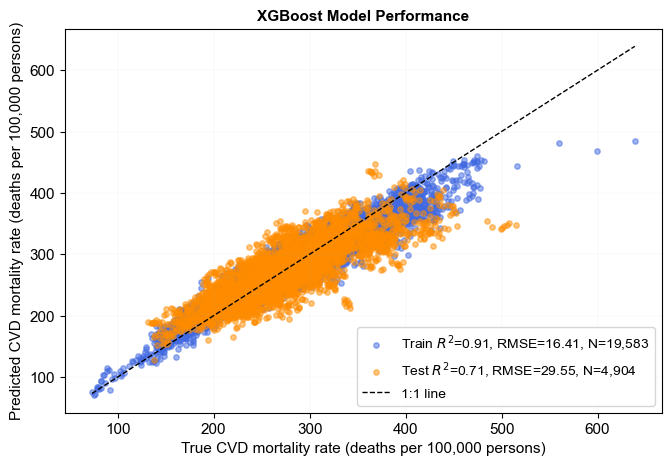

Saved scatter performance figure to: data_cvd/outputs/modeling/xgboost/revision/canonical_scatter_performance.png


In [8]:
scatter_path = OUTPUT_DIR / 'canonical_scatter_performance.png'
save_scatter_performance(y_train, train_pred, y_test, test_pred, scatter_path)
print(f'Saved scatter performance figure to: {project_relative_path(scatter_path)}')

## 6. Permutation-Based Feature Importance

Permutation importance estimates the decrease in predictive performance when each feature is randomly shuffled in the held-out test set. Larger decreases indicate stronger reliance of the fitted model on that predictor.

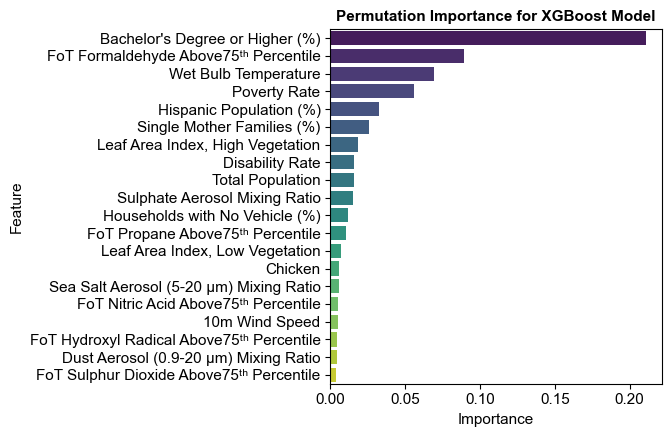

                              Feature                       Display Feature  Importance  Rank
      Bachelor's Degree or Higher (%)       Bachelor's Degree or Higher (%)    0.211090     1
FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile    0.089544     2
                 Wet Bulb Temperature                  Wet Bulb Temperature    0.069619     3
                         Poverty Rate                          Poverty Rate    0.055769     4
              Hispanic Population (%)               Hispanic Population (%)    0.032368     5
           Single Mother Families (%)            Single Mother Families (%)    0.025832     6
     Leaf Area Index, High Vegetation      Leaf Area Index, High Vegetation    0.018841     7
                      Disability Rate                       Disability Rate    0.015964     8
                     Total Population                      Total Population    0.015724     9
        Sulphate Aerosol Mixing Ratio         Sulphate Aeros

In [9]:
permutation_csv_path = OUTPUT_DIR / 'canonical_permutation_importance.csv'
permutation_fig_path = OUTPUT_DIR / 'canonical_permutation_importance.png'

permutation_importance_df = save_permutation_importance(
    canonical_model,
    X_test,
    y_test,
    permutation_csv_path,
    permutation_fig_path,
)

print(permutation_importance_df.head(10).to_string(index=False))
print(f'\nSaved permutation importance CSV to: {project_relative_path(permutation_csv_path)}')
print(f'Saved permutation importance figure to: {project_relative_path(permutation_fig_path)}')

## 7. SHAP Feature Attribution

SHAP values quantify each feature's contribution to individual model predictions. The ranking table summarizes mean absolute SHAP values across held-out county-year observations, and the beeswarm plot shows both magnitude and direction of feature effects.

Creating SHAP explainer...


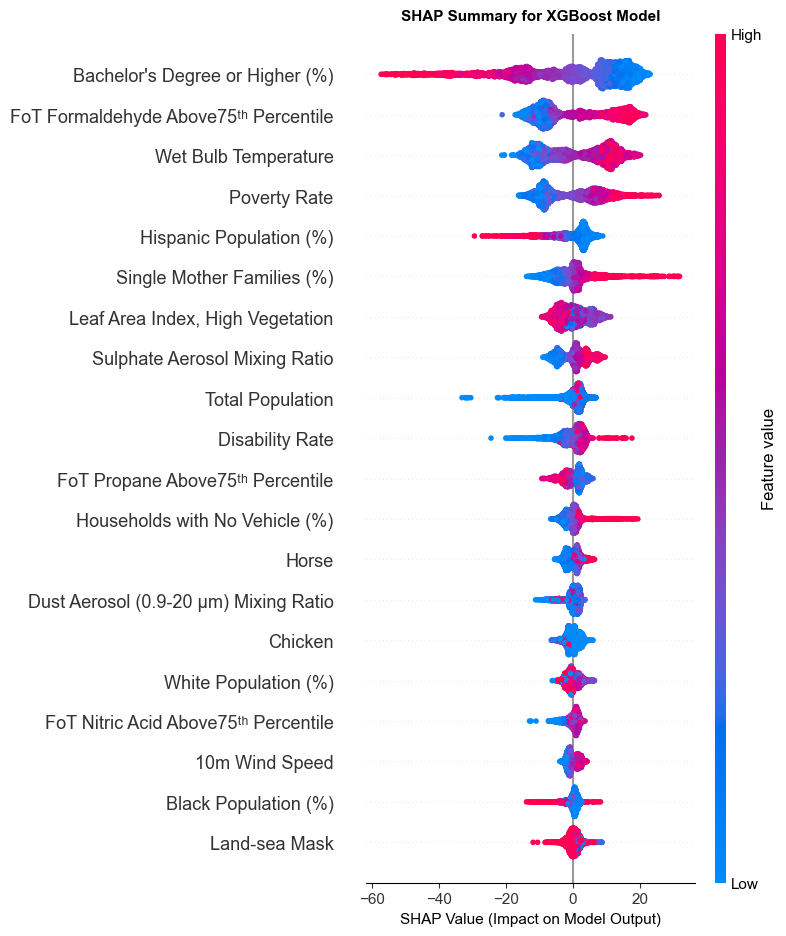

                              Feature                       Display Feature  Mean |SHAP|  Rank
      Bachelor's Degree or Higher (%)       Bachelor's Degree or Higher (%)    14.085009     1
FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile    10.183089     2
                 Wet Bulb Temperature                  Wet Bulb Temperature     9.369663     3
                         Poverty Rate                          Poverty Rate     7.957727     4
              Hispanic Population (%)               Hispanic Population (%)     4.194235     5
           Single Mother Families (%)            Single Mother Families (%)     3.981846     6
     Leaf Area Index, High Vegetation      Leaf Area Index, High Vegetation     3.511621     7
        Sulphate Aerosol Mixing Ratio         Sulphate Aerosol Mixing Ratio     3.390967     8
                     Total Population                      Total Population     2.765847     9
                      Disability Rate             

In [10]:
shap_ranking_path = OUTPUT_DIR / 'canonical_shap_ranking.csv'
shap_values_path = OUTPUT_DIR / 'canonical_shap_values.npy'
shap_summary_path = OUTPUT_DIR / 'canonical_shap_summary.png'

shap_values, shap_ranking_df = compute_and_save_shap(
    canonical_model,
    X_test,
    shap_ranking_path,
    shap_values_path,
    shap_summary_path,
)

print(shap_ranking_df.head(10).to_string(index=False))

formaldehyde_rank = shap_ranking_df.loc[
    shap_ranking_df['Feature'] == FORMALDEHYDE_FEATURE,
    'Rank'
]
if not formaldehyde_rank.empty:
    print(f'\nFormaldehyde SHAP rank: {int(formaldehyde_rank.iloc[0])}')
else:
    print('\nFormaldehyde feature was not found in the SHAP ranking table.')

print(f'\nSaved SHAP values to: {project_relative_path(shap_values_path)}')
print(f'Saved SHAP ranking CSV to: {project_relative_path(shap_ranking_path)}')
print(f'Saved SHAP summary figure to: {project_relative_path(shap_summary_path)}')

## 8. SHAP Dependence Profiles for Leading Predictors

Dependence plots show how feature values relate to their SHAP contributions for the three highest-ranked predictors. These plots help identify nonlinear patterns, threshold behavior, and the direction of model-attributed effects.

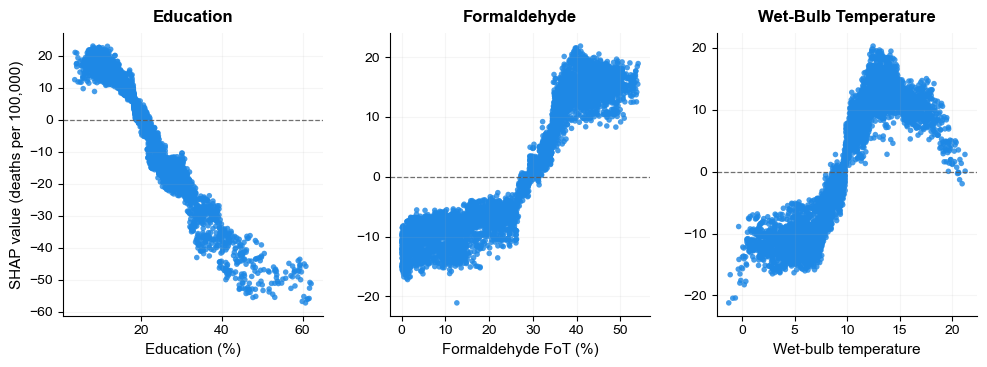

 Rank                               Feature                       Display Feature
    1       Bachelor's Degree or Higher (%)       Bachelor's degree or higher (%)
    2 FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile
    3                  Wet Bulb Temperature                  Wet-Bulb Temperature

Saved SHAP dependence CSV to: data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3_features.csv
Saved SHAP dependence figure to: data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3.png


In [11]:
shap_dependence_csv_path = OUTPUT_DIR / 'canonical_shap_dependence_top3_features.csv'
shap_dependence_fig_path = OUTPUT_DIR / 'canonical_shap_dependence_top3.png'

shap_dependence_df = save_shap_dependence_top3(
    X_test,
    shap_values,
    shap_ranking_df,
    shap_dependence_csv_path,
    shap_dependence_fig_path,
)

print(shap_dependence_df.to_string(index=False))
print(f'\nSaved SHAP dependence CSV to: {project_relative_path(shap_dependence_csv_path)}')
print(f'Saved SHAP dependence figure to: {project_relative_path(shap_dependence_fig_path)}')

## 9. Residual Diagnostics

Residual diagnostics assess whether prediction errors show systematic structure with respect to fitted values and socioeconomic context. The distribution panel summarizes the spread and centering of held-out prediction errors.

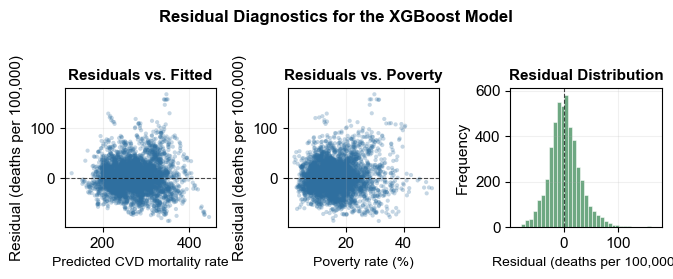

                        Metric       Value
                             N 4904.000000
                 Residual Mean    1.689358
               Residual Median   -0.105546
                   Residual SD   29.509057
                  Residual Min  -86.080127
                  Residual Max  167.894062
 Residual-Observed Correlation    0.548000
Residual-Predicted Correlation    0.008187
  Residual-Poverty Correlation    0.059472

Saved residual diagnostics summary to: data_cvd/outputs/modeling/xgboost/revision/canonical_residual_diagnostics_summary.csv
Saved residual diagnostics figure to: data_cvd/outputs/modeling/xgboost/revision/canonical_residual_diagnostics.png


In [12]:
residual_summary_path = OUTPUT_DIR / 'canonical_residual_diagnostics_summary.csv'
residual_fig_path = OUTPUT_DIR / 'canonical_residual_diagnostics.png'

residual_summary_df = save_residual_diagnostics(
    test_predictions,
    residual_summary_path,
    residual_fig_path,
)

print(residual_summary_df.to_string(index=False))
print(f'\nSaved residual diagnostics summary to: {project_relative_path(residual_summary_path)}')
print(f'Saved residual diagnostics figure to: {project_relative_path(residual_fig_path)}')

## 10. Artifact Verification

This final check verifies that all expected outputs from the preceding computations were written to disk. It is intended as a reproducibility guard before the outputs are used in manuscript figures, tables, or supplementary materials.

In [13]:
expected_outputs = [
    'canonical_split_metadata.csv',
    'canonical_model_metrics.csv',
    'canonical_train_predictions.csv',
    'canonical_test_predictions.csv',
    'canonical_shap_ranking.csv',
    'canonical_permutation_importance.csv',
    'canonical_shap_dependence_top3_features.csv',
    'canonical_residual_diagnostics_summary.csv',
    'canonical_scatter_performance.png',
    'canonical_shap_summary.png',
    'canonical_permutation_importance.png',
    'canonical_shap_dependence_top3.png',
    'canonical_residual_diagnostics.png',
    'canonical_shap_values.npy',
    'canonical_model.json',
]

missing_outputs = [name for name in expected_outputs if not (OUTPUT_DIR / name).exists()]

if missing_outputs:
    raise FileNotFoundError('Missing expected outputs: ' + ', '.join(missing_outputs))

print('Artifact checklist passed. All required files exist:')
for name in expected_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')

Artifact checklist passed. All required files exist:
- data_cvd/outputs/modeling/xgboost/revision/canonical_split_metadata.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_model_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_train_predictions.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_test_predictions.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_ranking.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_permutation_importance.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3_features.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_residual_diagnostics_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_scatter_performance.png
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_summary.png
- data_cvd/outputs/modeling/xgboost/revision/canonical_permutation_importance.png
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3.png
- d

## 11. Feature Ablation Study

This section evaluates how predictive performance changes when the model is restricted to progressively smaller feature subsets. Feature subsets are selected from the canonical SHAP ranking, and each reduced model uses the same county-grouped train-test split and fixed XGBoost hyperparameters as the baseline model.

### 11.1 Feature Subset Selection

The top 20, top 10, and top 5 predictor sets are selected from the canonical mean absolute SHAP ranking. These subsets preserve the feature ordering learned from the full model and avoid re-ranking predictors within reduced models.

In [20]:
shap_ranking_path = OUTPUT_DIR / 'canonical_shap_ranking.csv'
assert shap_ranking_path.exists(), f'Missing SHAP ranking file: {project_relative_path(shap_ranking_path)}'

canonical_shap_ranking_for_ablation = pd.read_csv(shap_ranking_path)
ranked_features = canonical_shap_ranking_for_ablation['Feature'].tolist()
missing_ranked_features = [feature for feature in ranked_features if feature not in X_train.columns]
if missing_ranked_features:
    raise KeyError(f'SHAP-ranked features not found in model matrix: {missing_ranked_features}')

top20_features = ranked_features[:20]
top10_features = ranked_features[:10]
top5_features = ranked_features[:5]

ablation_feature_sets = {
    'Top 20': top20_features,
    'Top 10': top10_features,
    'Top 5': top5_features,
}

subset_summary_df = pd.DataFrame([
    {
        'Feature Set': feature_set_name,
        'N': len(features),
        'Features': '; '.join(features),
    }
    for feature_set_name, features in ablation_feature_sets.items()
])

print(subset_summary_df.to_string(index=False))

Feature Set  N                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      Features
     Top 20 20 Bachelor's Degree or Higher (%); FoT Formaldehyde Above75ᵗʰ Percentile; Wet Bulb Temperature; Poverty Rate; Hispanic Population (%); Single Mother Families (%); Leaf Area Index, High Vegetation; Sulphate Aerosol Mixing Ratio; Total Population; Disability Rate; FoT Propane Above75ᵗʰ Percentile; Households with No Vehicle (%); Horse; Dust Aerosol (0.9-20 Μm) Mixing Ratio; Chicken; White Population (%); FoT Nitric Acid Above75ᵗʰ Percentile; 10m Wind Speed; Black Population (

### 11.2 Top-20 Feature Model

The top-20 model is trained using the 20 highest-ranked predictors from the full-model SHAP ranking. The train-test split and XGBoost hyperparameters are unchanged from the baseline model.

In [21]:
def train_and_evaluate_ablation_model(feature_set_name, selected_features):
    model = xgb.XGBRegressor(**CVD_HYPERPARAMETERS)
    model.fit(X_train[selected_features], y_train)

    train_predictions_subset = model.predict(X_train[selected_features])
    test_predictions_subset = model.predict(X_test[selected_features])
    n_features = len(selected_features)

    metrics = {
        'Feature Set': feature_set_name,
        'N': n_features,
        'Test R²': float(r2_score(y_test, test_predictions_subset)),
        'Test Adj R²': float(adjusted_r2_score(y_test, test_predictions_subset, n_features)),
        'Test RMSE': float(rmse_score(y_test, test_predictions_subset)),
        'Test MAE': float(mean_absolute_error(y_test, test_predictions_subset)),
    }

    train_metrics = {
        'Train R²': float(r2_score(y_train, train_predictions_subset)),
        'Train RMSE': float(rmse_score(y_train, train_predictions_subset)),
        'Train MAE': float(mean_absolute_error(y_train, train_predictions_subset)),
    }

    return model, metrics, train_metrics


top20_model, top20_metrics, top20_train_metrics = train_and_evaluate_ablation_model('Top 20', top20_features)

print('Top-20 feature model metrics')
print(pd.DataFrame([{**top20_train_metrics, **top20_metrics}]).to_string(index=False))

Top-20 feature model metrics
 Train R²  Train RMSE  Train MAE Feature Set  N  Test R²  Test Adj R²  Test RMSE  Test MAE
 0.900521   17.329629  13.051048      Top 20 20 0.703499     0.702285  29.689626 22.345708


### 11.3 Top-10 Feature Model

The top-10 model repeats the fixed-parameter fit using the 10 highest-ranked predictors from the canonical SHAP ranking.

In [22]:
top10_model, top10_metrics, top10_train_metrics = train_and_evaluate_ablation_model('Top 10', top10_features)

print('Top-10 feature model metrics')
print(pd.DataFrame([{**top10_train_metrics, **top10_metrics}]).to_string(index=False))

Top-10 feature model metrics
 Train R²  Train RMSE  Train MAE Feature Set  N  Test R²  Test Adj R²  Test RMSE  Test MAE
 0.858969   20.633842   15.55145      Top 10 10 0.678905     0.678249  30.896447 22.976928


### 11.4 Top-5 Feature Model

The top-5 model evaluates the most compact feature subset considered in the ablation analysis, again using the same train-test split and fixed XGBoost hyperparameters.

In [23]:
top5_model, top5_metrics, top5_train_metrics = train_and_evaluate_ablation_model('Top 5', top5_features)

print('Top-5 feature model metrics')
print(pd.DataFrame([{**top5_train_metrics, **top5_metrics}]).to_string(index=False))

Top-5 feature model metrics
 Train R²  Train RMSE  Train MAE Feature Set  N  Test R²  Test Adj R²  Test RMSE  Test MAE
 0.747396   27.614882  20.965681       Top 5  5 0.628954     0.628576  33.212811 25.035898


### 11.5 Ablation Summary Table and Curve

The full-model row is read from the canonical metrics CSV so that the ablation table remains exactly consistent with the baseline model outputs. The curve visualizes the tradeoff between feature-count reduction and held-out test performance.

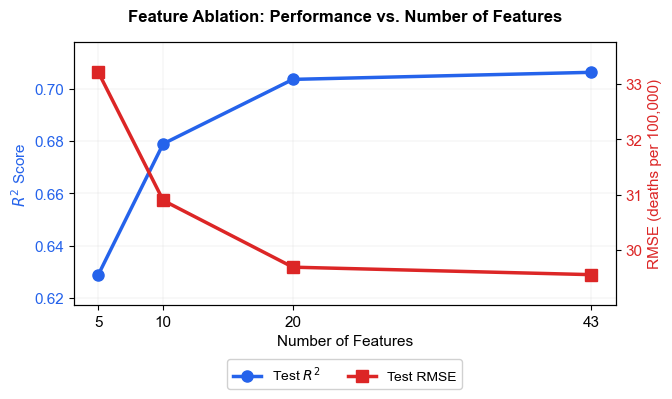

Canonical feature ablation summary
 Feature Set  N  Test R²  Test Adj R²  Test RMSE  Test MAE
All Features 43    0.706        0.704     29.554    22.184
      Top 20 20    0.703        0.702     29.690    22.346
      Top 10 10    0.679        0.678     30.896    22.977
       Top 5  5    0.629        0.629     33.213    25.036

Saved ablation metrics to: data_cvd/outputs/modeling/xgboost/revision/canonical_ablation_metrics.csv
Saved ablation curve to: data_cvd/outputs/modeling/xgboost/revision/canonical_ablation_curve.png


In [24]:
def extract_test_metric(metrics_df, metric_name):
    matches = metrics_df.loc[metrics_df['Metric'] == metric_name, 'Test Set']
    if matches.empty:
        raise KeyError(f'Metric not found in canonical_model_metrics.csv: {metric_name}')
    return float(matches.iloc[0])


canonical_metrics_path = OUTPUT_DIR / 'canonical_model_metrics.csv'
assert canonical_metrics_path.exists(), f'Missing canonical metrics file: {project_relative_path(canonical_metrics_path)}'
canonical_metrics_for_ablation = pd.read_csv(canonical_metrics_path)

full_model_row = {
    'Feature Set': 'All Features',
    'N': EXPECTED_N_FEATURES,
    'Test R²': extract_test_metric(canonical_metrics_for_ablation, 'R² Score'),
    'Test Adj R²': extract_test_metric(canonical_metrics_for_ablation, 'Adjusted R²'),
    'Test RMSE': extract_test_metric(canonical_metrics_for_ablation, 'RMSE (per 100,000)'),
    'Test MAE': extract_test_metric(canonical_metrics_for_ablation, 'MAE (per 100,000)'),
}

ablation_metrics_df = pd.DataFrame([
    full_model_row,
    top20_metrics,
    top10_metrics,
    top5_metrics,
], columns=['Feature Set', 'N', 'Test R²', 'Test Adj R²', 'Test RMSE', 'Test MAE'])

ablation_metrics_path = OUTPUT_DIR / 'canonical_ablation_metrics.csv'
ablation_metrics_df.to_csv(ablation_metrics_path, index=False)

plot_df = ablation_metrics_df.sort_values('N')
fig, ax1 = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.6))

color1 = '#2563eb'
ax1.set_xlabel('Number of Features', fontsize=FONT_SIZE)
ax1.set_ylabel('$R^2$ Score', color=color1, fontsize=FONT_SIZE)
line1 = ax1.plot(
    plot_df['N'],
    plot_df['Test R²'],
    marker='o',
    markersize=8,
    linewidth=2.5,
    color=color1,
    label='Test $R^2$',
)
ax1.tick_params(axis='y', labelcolor=color1)
r2_min = plot_df['Test R²'].min()
r2_max = plot_df['Test R²'].max()
r2_padding = (r2_max - r2_min) * 0.15 if r2_max > r2_min else 0.05
ax1.set_ylim([r2_min - r2_padding, min(1.0, r2_max + r2_padding)])
ax1.grid(axis='both', linewidth=0.3, alpha=0.4)

ax2 = ax1.twinx()
color2 = '#dc2626'
ax2.set_ylabel('RMSE (deaths per 100,000)', color=color2, fontsize=FONT_SIZE)
line2 = ax2.plot(
    plot_df['N'],
    plot_df['Test RMSE'],
    marker='s',
    markersize=8,
    linewidth=2.5,
    color=color2,
    label='Test RMSE',
)
ax2.tick_params(axis='y', labelcolor=color2)
rmse_min = plot_df['Test RMSE'].min()
rmse_max = plot_df['Test RMSE'].max()
rmse_padding = (rmse_max - rmse_min) * 0.15 if rmse_max > rmse_min else 0.05
ax2.set_ylim([max(0, rmse_min - rmse_padding), rmse_max + rmse_padding])

ax1.set_title('Feature Ablation: Performance vs. Number of Features', fontsize=FONT_SIZE + 1, fontweight='bold', pad=15)
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(
    lines,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    fontsize=FONT_SIZE - 1,
    framealpha=0.9,
)
ax1.set_xticks(plot_df['N'])
ax1.set_xticklabels(plot_df['N'].astype(int))

plt.tight_layout()
fig.subplots_adjust(bottom=0.24)
ablation_curve_path = OUTPUT_DIR / 'canonical_ablation_curve.png'
plt.savefig(ablation_curve_path, dpi=DPI, bbox_inches='tight')
plt.show()

print('Canonical feature ablation summary')
print(ablation_metrics_df.to_string(index=False, float_format=lambda value: f'{value:.3f}'))
print(f'\nSaved ablation metrics to: {project_relative_path(ablation_metrics_path)}')
print(f'Saved ablation curve to: {project_relative_path(ablation_curve_path)}')

### 11.6 Ablation Artifact Verification

This check verifies that the ablation summary table and figure were written to the configured output directory.

In [25]:
expected_ablation_outputs = [
    'canonical_ablation_metrics.csv',
    'canonical_ablation_curve.png',
]

missing_ablation_outputs = [name for name in expected_ablation_outputs if not (OUTPUT_DIR / name).exists()]
if missing_ablation_outputs:
    raise FileNotFoundError('Missing ablation outputs: ' + ', '.join(missing_ablation_outputs))

print('Ablation artifact check passed:')
for name in expected_ablation_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')

Ablation artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/canonical_ablation_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_ablation_curve.png


## 12. Feature-Selection Audit and Pruning-Impact Check

This section documents the feature-reduction procedure used before model fitting and evaluates whether the reduced predictor set preserves predictive performance. It consolidates previously generated feature-selection outputs and fits one fixed-parameter comparison model using the unreduced candidate feature set on the same held-out counties as the canonical model.


### 12.1 Existing Correlation-Screening Outputs

The socioeconomic and atmospheric feature-screening notebooks produced correlation-pair tables and keep/drop recommendations for predictors with high pairwise correlation. These existing outputs are combined into a single reviewer-facing table without repeating the original feature-screening analysis.


In [26]:
FEATURE_ANALYSIS_DIR = PROJECT_ROOT / 'data_cvd' / 'outputs' / 'feature_analysis'
FEATURE_SELECTION_SOURCE_PATHS = {
    'demographic_correlated_pairs': FEATURE_ANALYSIS_DIR / 'high_correlation_pairs.csv',
    'weather_correlated_pairs': FEATURE_ANALYSIS_DIR / 'weather_high_correlation_pairs.csv',
    'demographic_recommendations': FEATURE_ANALYSIS_DIR / 'feature_selection_recommendations.csv',
    'weather_recommendations': FEATURE_ANALYSIS_DIR / 'weather_feature_selection_recommendations.csv',
    'demographic_decision_metrics': FEATURE_ANALYSIS_DIR / 'feature_decision_metrics.csv',
    'weather_decision_metrics': FEATURE_ANALYSIS_DIR / 'weather_feature_decision_metrics.csv',
}

missing_feature_selection_sources = [
    project_relative_path(path)
    for path in FEATURE_SELECTION_SOURCE_PATHS.values()
    if not path.exists()
]
if missing_feature_selection_sources:
    raise FileNotFoundError(
        'Missing feature-selection source files: ' + ', '.join(str(path) for path in missing_feature_selection_sources)
    )


def load_feature_selection_source(source_key):
    path = FEATURE_SELECTION_SOURCE_PATHS[source_key]
    source_df = pd.read_csv(path)
    print(f'Loaded {source_key}: {source_df.shape[0]} rows from {project_relative_path(path)}')
    return source_df


demographic_correlated_pairs = load_feature_selection_source('demographic_correlated_pairs')
weather_correlated_pairs = load_feature_selection_source('weather_correlated_pairs')
demographic_recommendations = load_feature_selection_source('demographic_recommendations')
weather_recommendations = load_feature_selection_source('weather_recommendations')


def add_feature_domain(source_df, domain):
    output_df = source_df.copy()
    output_df.insert(0, 'Domain', domain)
    return output_df


feature_selection_correlated_pairs_df = pd.concat(
    [
        add_feature_domain(demographic_correlated_pairs, 'Socioeconomic and Demographic'),
        add_feature_domain(weather_correlated_pairs, 'Atmospheric and Meteorological'),
    ],
    ignore_index=True,
)
feature_selection_correlated_pairs_df['Absolute Correlation'] = feature_selection_correlated_pairs_df['Correlation'].abs()
feature_selection_correlated_pairs_df = feature_selection_correlated_pairs_df.sort_values(
    ['Domain', 'Absolute Correlation'], ascending=[True, False]
).reset_index(drop=True)

feature_selection_correlated_pairs_path = OUTPUT_DIR / 'feature_selection_correlated_pairs.csv'
feature_selection_correlated_pairs_df.to_csv(feature_selection_correlated_pairs_path, index=False)

print(f'\nSaved combined high-correlation table to: {project_relative_path(feature_selection_correlated_pairs_path)}')
print(feature_selection_correlated_pairs_df.groupby('Domain').size().rename('Pairs with |r| > 0.85').to_string())
print('\nStrongest correlated pairs:')
print(feature_selection_correlated_pairs_df.head(10).to_string(index=False))


Loaded demographic_correlated_pairs: 1 rows from data_cvd/outputs/feature_analysis/high_correlation_pairs.csv
Loaded weather_correlated_pairs: 26 rows from data_cvd/outputs/feature_analysis/weather_high_correlation_pairs.csv
Loaded demographic_recommendations: 1 rows from data_cvd/outputs/feature_analysis/feature_selection_recommendations.csv
Loaded weather_recommendations: 26 rows from data_cvd/outputs/feature_analysis/weather_feature_selection_recommendations.csv

Saved combined high-correlation table to: data_cvd/outputs/modeling/xgboost/revision/feature_selection_correlated_pairs.csv
Domain
Atmospheric and Meteorological    26
Socioeconomic and Demographic      1

Strongest correlated pairs:
                        Domain                                      Variable 1                                      Variable 2  Correlation  Absolute Correlation
Atmospheric and Meteorological     Sea salt aerosol (0.03-0.5 µm) mixing ratio        Sea salt aerosol (0.5-5 µm) mixing ratio     0.

### 12.2 Final Drop-List Documentation

The final drop list is derived by comparing normalized feature names in the current unreduced and reduced datasets. This avoids misclassifying variables that were retained under title-case or typographic name formatting in the reduced modeling file.


In [ ]:
UNREDUCED_DATA_PATH = PROJECT_ROOT / 'data_cvd' / 'combined_final' / 'final_combined_all_variables.csv'
assert UNREDUCED_DATA_PATH.exists(), f'Missing unreduced dataset: {project_relative_path(UNREDUCED_DATA_PATH)}'
assert DATA_PATH.exists(), f'Missing reduced dataset: {project_relative_path(DATA_PATH)}'

import re


def normalize_feature_name(name):
    normalized = clean_display_label(str(name))
    normalized = normalized.replace('Μ', 'µ').replace('μ', 'µ').replace('ᵗʰ', 'th')
    normalized = re.sub(r'\s+', ' ', normalized).strip().lower()
    return normalized


unreduced_columns = pd.read_csv(UNREDUCED_DATA_PATH, nrows=0).columns.tolist()
reduced_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
identifier_candidates = ['County', 'State', YEAR_COL, 'Fips', 'fips']
unreduced_feature_cols_for_audit = [
    col for col in unreduced_columns
    if col not in identifier_candidates + [TARGET_COL]
]
reduced_feature_cols_for_audit = [
    col for col in reduced_columns
    if col not in identifier_candidates + [TARGET_COL]
]

reduced_feature_by_normalized_name = {
    normalize_feature_name(col): col
    for col in reduced_feature_cols_for_audit
}
unreduced_normalized_names = {
    normalize_feature_name(col)
    for col in unreduced_feature_cols_for_audit
}

unmatched_reduced_features = [
    col for col in reduced_feature_cols_for_audit
    if normalize_feature_name(col) not in unreduced_normalized_names
]
if unmatched_reduced_features:
    raise ValueError(
        'Reduced features could not be matched to the unreduced dataset after name normalization: '
        + ', '.join(unmatched_reduced_features)
    )

actual_dropped_features = [
    col for col in unreduced_feature_cols_for_audit
    if normalize_feature_name(col) not in reduced_feature_by_normalized_name
]
actual_retained_feature_pairs = [
    {
        'Unreduced Feature': col,
        'Reduced Feature': reduced_feature_by_normalized_name[normalize_feature_name(col)],
    }
    for col in unreduced_feature_cols_for_audit
    if normalize_feature_name(col) in reduced_feature_by_normalized_name
]

if len(actual_retained_feature_pairs) != len(reduced_feature_cols_for_audit):
    raise ValueError('Feature-name normalization did not create a one-to-one retained-feature mapping.')

# Socioeconomic features removed during the demographic feature-screening stage.
demographics_to_drop = [
    'Rent Burden (+50% of HI)',
    'Median Household Income',
    'Gini Index',
    'High School Degree or Higher (%)',
    'Median Age',
]
demographic_drop_names = {normalize_feature_name(feature) for feature in demographics_to_drop}

recommendation_frames = []
for domain, source_df in [
    ('Socioeconomic and Demographic', demographic_recommendations),
    ('Atmospheric and Meteorological', weather_recommendations),
]:
    recommendation_df = source_df.copy()
    recommendation_df['Domain'] = domain
    recommendation_df['Normalized Drop'] = recommendation_df['Drop'].map(normalize_feature_name)
    recommendation_frames.append(recommendation_df)
recommendations_df = pd.concat(recommendation_frames, ignore_index=True)

recommendation_records = []
for normalized_drop, group_df in recommendations_df.groupby('Normalized Drop'):
    evidence_parts = []
    reason_parts = []
    for _, row in group_df.iterrows():
        evidence_parts.append(
            f"{row['Correlated Pair']} (r={row['Correlation']:.3f}; retained {row['Keep']})"
        )
        reason_parts.append(str(row['Reason']))
    recommendation_records.append({
        'Normalized Feature': normalized_drop,
        'Correlation Screen Evidence': '; '.join(evidence_parts),
        'Recommendation Rule': '; '.join(pd.unique(reason_parts)),
    })
recommendation_details_df = pd.DataFrame(recommendation_records)
recommendation_details_by_feature = recommendation_details_df.set_index('Normalized Feature').to_dict(orient='index')

remote_sensing_product_terms = [
    'aod at',
    'pm$_',
    'total column',
    'vertically integrated mass',
    'epa threshold',
    'temperature above 90',
    'temperature below 0',
]
raw_atmospheric_species = {
    normalize_feature_name(feature)
    for feature in [
        'Carbon monoxide', 'Ethane', 'Formaldehyde', 'Hydrogen peroxide', 'Hydroxyl radical',
        'Isoprene', 'Nitric acid', 'Nitrogen dioxide', 'Nitrogen monoxide', 'Ozone',
        'Peroxyacetyl nitrate', 'Propane', 'Sulphur dioxide', 'Temperature',
        'Specific humidity', 'Specific humidity.1', 'Relative humidity', 'Snow albedo',
        'Surface geopotential', 'Surface pressure', '2m dew point temperature', '2m temperature',
        'Total column water', 'Buffalo',
    ]
}


def classify_dropped_feature(feature):
    normalized_feature = normalize_feature_name(feature)
    if normalized_feature in demographic_drop_names:
        return {
            'Domain': 'Socioeconomic and Demographic',
            'Drop Category': 'Socioeconomic feature pruning',
            'Decision Basis': 'Removed after demographic correlation, target-correlation, VIF, and interpretability review.',
            'Source Notebook': 'notebooks_cvd/06_feature_analysis_demographics.ipynb; notebooks_cvd/08_create_final_reduced_dataset.ipynb',
        }
    if normalized_feature == normalize_feature_name('Buffalo'):
        return {
            'Domain': 'Livestock',
            'Drop Category': 'Livestock scope exclusion',
            'Decision Basis': 'Removed because Buffalo was not part of the final livestock predictor set used for model interpretation.',
            'Source Notebook': 'notebooks_cvd/08_create_final_reduced_dataset.ipynb',
        }
    if normalized_feature in recommendation_details_by_feature:
        return {
            'Domain': 'Atmospheric and Meteorological',
            'Drop Category': 'High-correlation feature pruning',
            'Decision Basis': 'Removed after pairwise-correlation screening using target correlation, VIF, and domain interpretability.',
            'Source Notebook': 'notebooks_cvd/07_feature_analysis_weather.ipynb; notebooks_cvd/08_create_final_reduced_dataset.ipynb',
        }
    if any(term in normalized_feature for term in remote_sensing_product_terms) or normalized_feature in raw_atmospheric_species:
        return {
            'Domain': 'Atmospheric and Meteorological',
            'Drop Category': 'Remote-sensing product consolidation',
            'Decision Basis': 'Removed as a lower-priority or redundant atmospheric product relative to retained exposure summaries.',
            'Source Notebook': 'notebooks_cvd/07_feature_analysis_weather.ipynb; notebooks_cvd/08_create_final_reduced_dataset.ipynb',
        }
    return {
        'Domain': 'Atmospheric and Meteorological',
        'Drop Category': 'Final atmospheric redundancy pruning',
        'Decision Basis': 'Removed during final atmospheric predictor consolidation.',
        'Source Notebook': 'notebooks_cvd/07_feature_analysis_weather.ipynb; notebooks_cvd/08_create_final_reduced_dataset.ipynb',
    }


drop_records = []
for feature in actual_dropped_features:
    normalized_feature = normalize_feature_name(feature)
    classification = classify_dropped_feature(feature)
    recommendation_details = recommendation_details_by_feature.get(normalized_feature, {})
    drop_records.append({
        'Variable': feature,
        'Normalized Variable': normalized_feature,
        **classification,
        'Correlation Screen Evidence': recommendation_details.get(
            'Correlation Screen Evidence',
            'Not a direct pairwise-correlation drop in the final consolidated list',
        ),
        'Recommendation Rule': recommendation_details.get(
            'Recommendation Rule',
            'Final consolidated pruning decision documented by current unreduced-versus-reduced dataset comparison',
        ),
        'Present in Unreduced Dataset': True,
        'Present in Reduced Dataset': False,
    })

feature_selection_drop_list_df = pd.DataFrame(drop_records)
feature_selection_drop_list_path = OUTPUT_DIR / 'feature_selection_drop_list.csv'
feature_selection_drop_list_df.to_csv(feature_selection_drop_list_path, index=False)

print(f'Saved feature-selection drop list to: {project_relative_path(feature_selection_drop_list_path)}')
print(feature_selection_drop_list_df.groupby(['Domain', 'Drop Category']).size().rename('Dropped Variables').to_string())
print(f"\nUnreduced candidate predictors: {len(unreduced_feature_cols_for_audit)}")
print(f"Retained predictors after name normalization: {len(actual_retained_feature_pairs)}")
print(f"Dropped predictors after name normalization: {len(actual_dropped_features)}")
print(f"Reduced candidate predictors: {len(reduced_feature_cols_for_audit)}")


### 12.3 Feature-Selection Summary

This summary records the dataset dimensions, number of candidate predictors before and after feature reduction, and the number of variables documented in each pruning category. The counts are derived from the current unreduced and reduced modeling files after feature-name normalization.


In [ ]:
unreduced_shape_df = pd.read_csv(UNREDUCED_DATA_PATH)
reduced_shape_df = pd.read_csv(DATA_PATH)

unreduced_identifier_cols = [col for col in ['County', 'State', YEAR_COL, 'Fips', 'fips'] if col in unreduced_shape_df.columns]
reduced_identifier_cols = [col for col in ['County', 'State', YEAR_COL, 'Fips', 'fips'] if col in reduced_shape_df.columns]

unreduced_feature_count = len(unreduced_feature_cols_for_audit)
reduced_feature_count = len(reduced_feature_cols_for_audit)

drop_category_counts = feature_selection_drop_list_df.groupby('Drop Category').size().to_dict()

feature_selection_summary_df = pd.DataFrame([
    {'Quantity': 'Unreduced dataset rows', 'Value': unreduced_shape_df.shape[0], 'Notes': project_relative_path(UNREDUCED_DATA_PATH)},
    {'Quantity': 'Unreduced dataset columns', 'Value': unreduced_shape_df.shape[1], 'Notes': 'Includes identifiers and target'},
    {'Quantity': 'Unreduced candidate predictors', 'Value': unreduced_feature_count, 'Notes': 'Columns after removing identifiers and CVD mortality target'},
    {'Quantity': 'Reduced dataset rows', 'Value': reduced_shape_df.shape[0], 'Notes': project_relative_path(DATA_PATH)},
    {'Quantity': 'Reduced dataset columns', 'Value': reduced_shape_df.shape[1], 'Notes': 'Includes identifiers and target'},
    {'Quantity': 'Reduced candidate predictors', 'Value': reduced_feature_count, 'Notes': 'Canonical XGBoost predictor count'},
    {'Quantity': 'Documented dropped predictors', 'Value': feature_selection_drop_list_df.shape[0], 'Notes': 'Current unreduced-versus-reduced dataset comparison after name normalization'},
    {'Quantity': 'Retained predictor mappings', 'Value': len(actual_retained_feature_pairs), 'Notes': 'Unreduced features matched to reduced features after title-case and typographic normalization'},
    {'Quantity': 'Socioeconomic feature pruning drops', 'Value': drop_category_counts.get('Socioeconomic feature pruning', 0), 'Notes': 'Based on demographic correlation, target-correlation, VIF, and interpretability review'},
    {'Quantity': 'High-correlation feature pruning drops', 'Value': drop_category_counts.get('High-correlation feature pruning', 0), 'Notes': 'Based on |r| > 0.85 pairwise correlation screen'},
    {'Quantity': 'Remote-sensing product consolidation drops', 'Value': drop_category_counts.get('Remote-sensing product consolidation', 0), 'Notes': 'Lower-priority or redundant atmospheric products removed during predictor consolidation'},
    {'Quantity': 'Final atmospheric redundancy pruning drops', 'Value': drop_category_counts.get('Final atmospheric redundancy pruning', 0), 'Notes': 'Additional atmospheric predictors removed during final consolidation'},
    {'Quantity': 'Livestock scope exclusion drops', 'Value': drop_category_counts.get('Livestock scope exclusion', 0), 'Notes': 'Buffalo excluded from final livestock predictor set'},
    {'Quantity': 'High-correlation pairs documented', 'Value': feature_selection_correlated_pairs_df.shape[0], 'Notes': 'Pairs with |r| > 0.85 from notebooks 06 and 07'},
    {'Quantity': 'Feature-selection decision rule', 'Value': 'target correlation + VIF + domain interpretability', 'Notes': 'Used to select retained variables among highly correlated or redundant alternatives'},
])

feature_selection_summary_path = OUTPUT_DIR / 'feature_selection_summary.csv'
feature_selection_summary_df.to_csv(feature_selection_summary_path, index=False)

print(f'Saved feature-selection summary to: {project_relative_path(feature_selection_summary_path)}')
print(feature_selection_summary_df.to_string(index=False))


### 12.4 Unreduced Candidate Feature Model

A single comparison model is trained on the unreduced candidate feature matrix using the same XGBoost hyperparameters and the same held-out counties as the canonical reduced model. This evaluates whether feature pruning materially changed predictive performance without producing additional interpretability artifacts for the unreduced model.


In [29]:
canonical_test_predictions_path = OUTPUT_DIR / 'canonical_test_predictions.csv'
canonical_split_metadata_path = OUTPUT_DIR / 'canonical_split_metadata.csv'
assert canonical_test_predictions_path.exists(), f'Missing canonical test predictions: {project_relative_path(canonical_test_predictions_path)}'
assert canonical_split_metadata_path.exists(), f'Missing canonical split metadata: {project_relative_path(canonical_split_metadata_path)}'

unreduced_df = pd.read_csv(UNREDUCED_DATA_PATH)
full_group_col = 'Fips' if 'Fips' in unreduced_df.columns else 'fips'
required_unreduced_columns = [TARGET_COL, full_group_col, YEAR_COL]
missing_unreduced_columns = [col for col in required_unreduced_columns if col not in unreduced_df.columns]
if missing_unreduced_columns:
    raise KeyError(f'Missing required unreduced dataset columns: {missing_unreduced_columns}')

print(f'Loaded unreduced dataset shape: {unreduced_df.shape}')
print(f'Unreduced group column: {full_group_col}')
print('\nRaw unreduced target distribution before scaling:')
print(unreduced_df[TARGET_COL].describe())

unreduced_raw_target_max = unreduced_df[TARGET_COL].max()
if unreduced_raw_target_max > 1:
    raise ValueError(
        f'{TARGET_COL} in the unreduced dataset appears already scaled; '
        f'max={unreduced_raw_target_max:.4f}. Do not multiply again.'
    )

unreduced_model_df = unreduced_df.copy()
unreduced_model_df[TARGET_COL] = unreduced_model_df[TARGET_COL] * 100000

unreduced_identifier_cols_for_model = [
    col for col in ['County', 'State', YEAR_COL, 'Fips', 'fips']
    if col in unreduced_model_df.columns
]
unreduced_feature_cols = [
    col for col in unreduced_model_df.columns
    if col not in unreduced_identifier_cols_for_model + [TARGET_COL]
]

unreduced_X = unreduced_model_df[unreduced_feature_cols].copy()
unreduced_y = unreduced_model_df[TARGET_COL].copy()
non_numeric_unreduced_features = unreduced_X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_unreduced_features:
    raise TypeError(
        'Unreduced feature matrix contains non-numeric predictors: ' + ', '.join(non_numeric_unreduced_features)
    )

canonical_test_predictions_for_split = pd.read_csv(canonical_test_predictions_path)
canonical_test_fips = set(canonical_test_predictions_for_split[GROUP_COL].astype(int))
unreduced_fips = unreduced_model_df[full_group_col].astype(int)

unreduced_test_mask = unreduced_fips.isin(canonical_test_fips)
unreduced_train_mask = ~unreduced_test_mask

canonical_split_metadata_for_check = pd.read_csv(canonical_split_metadata_path)
expected_train_rows = int(canonical_split_metadata_for_check.loc[0, 'Train Rows'])
expected_test_rows = int(canonical_split_metadata_for_check.loc[0, 'Test Rows'])
expected_train_counties = int(canonical_split_metadata_for_check.loc[0, 'Train Counties'])
expected_test_counties = int(canonical_split_metadata_for_check.loc[0, 'Test Counties'])

train_counties_unreduced = set(unreduced_fips.loc[unreduced_train_mask])
test_counties_unreduced = set(unreduced_fips.loc[unreduced_test_mask])
county_overlap_unreduced = train_counties_unreduced.intersection(test_counties_unreduced)

split_checks = {
    'train_rows_match': int(unreduced_train_mask.sum()) == expected_train_rows,
    'test_rows_match': int(unreduced_test_mask.sum()) == expected_test_rows,
    'train_counties_match': len(train_counties_unreduced) == expected_train_counties,
    'test_counties_match': len(test_counties_unreduced) == expected_test_counties,
    'zero_county_overlap': len(county_overlap_unreduced) == 0,
}
failed_split_checks = [name for name, passed in split_checks.items() if not passed]
if failed_split_checks:
    raise ValueError(f'Unreduced model split does not match canonical held-out counties: {failed_split_checks}')

unreduced_X_train = unreduced_X.loc[unreduced_train_mask].copy()
unreduced_X_test = unreduced_X.loc[unreduced_test_mask].copy()
unreduced_y_train = unreduced_y.loc[unreduced_train_mask].copy()
unreduced_y_test = unreduced_y.loc[unreduced_test_mask].copy()

unreduced_feature_count = unreduced_X.shape[1]

unreduced_model = xgb.XGBRegressor(**CVD_HYPERPARAMETERS)
unreduced_model.fit(unreduced_X_train, unreduced_y_train)

unreduced_train_predictions = unreduced_model.predict(unreduced_X_train)
unreduced_test_predictions = unreduced_model.predict(unreduced_X_test)

feature_selection_unreduced_metrics_df = evaluate_model(
    unreduced_y_train,
    unreduced_train_predictions,
    unreduced_y_test,
    unreduced_test_predictions,
    unreduced_feature_count,
)

feature_selection_unreduced_metrics_path = OUTPUT_DIR / 'feature_selection_unreduced_model_metrics.csv'
feature_selection_unreduced_metrics_df.to_csv(feature_selection_unreduced_metrics_path, index=False)

print(f'Unreduced candidate predictor count: {unreduced_feature_count}')
print(f'Train rows: {unreduced_X_train.shape[0]:,}; test rows: {unreduced_X_test.shape[0]:,}')
print(f'Train counties: {len(train_counties_unreduced):,}; test counties: {len(test_counties_unreduced):,}; overlap: {len(county_overlap_unreduced)}')
print(f'Saved unreduced model metrics to: {project_relative_path(feature_selection_unreduced_metrics_path)}')
print(feature_selection_unreduced_metrics_df.to_string(index=False))


Loaded unreduced dataset shape: (24487, 131)
Unreduced group column: fips

Raw unreduced target distribution before scaling:
count    24487.000000
mean         0.002709
std          0.000549
min          0.000731
25%          0.002310
50%          0.002653
75%          0.003059
max          0.006389
Name: CVD Mortality Rate, dtype: float64
Unreduced candidate predictor count: 126
Train rows: 19,583; test rows: 4,904
Train counties: 2,448; test counties: 613; overlap: 0
Saved unreduced model metrics to: data_cvd/outputs/modeling/xgboost/revision/feature_selection_unreduced_model_metrics.csv
            Metric  Training Set    Test Set
          R² Score      0.920887    0.722408
       Adjusted R²      0.920375    0.715086
RMSE (per 100,000)     15.454228   28.727349
 MAE (per 100,000)     11.618948   21.564432
       Sample Size  19583.000000 4904.000000


### 12.5 Reduced-versus-Unreduced Model Comparison

The canonical 43-feature model metrics are read from disk and compared with the unreduced candidate-feature model. This table keeps the feature-selection comparison consistent with the canonical model results used elsewhere in the manuscript.


In [30]:
def get_metric_value(metrics_df, metric_name, split_name):
    matches = metrics_df.loc[metrics_df['Metric'] == metric_name, split_name]
    if matches.empty:
        raise KeyError(f'Metric not found: {metric_name} / {split_name}')
    return float(matches.iloc[0])


canonical_metrics_for_feature_selection_path = OUTPUT_DIR / 'canonical_model_metrics.csv'
assert canonical_metrics_for_feature_selection_path.exists(), f'Missing canonical metrics: {project_relative_path(canonical_metrics_for_feature_selection_path)}'
canonical_metrics_for_feature_selection = pd.read_csv(canonical_metrics_for_feature_selection_path)

reduced_feature_selection_row = {
    'Model': 'Reduced 43-feature canonical model',
    'N Features': EXPECTED_N_FEATURES,
    'Train R²': get_metric_value(canonical_metrics_for_feature_selection, 'R² Score', 'Training Set'),
    'Test R²': get_metric_value(canonical_metrics_for_feature_selection, 'R² Score', 'Test Set'),
    'Test Adj R²': get_metric_value(canonical_metrics_for_feature_selection, 'Adjusted R²', 'Test Set'),
    'Test RMSE': get_metric_value(canonical_metrics_for_feature_selection, 'RMSE (per 100,000)', 'Test Set'),
    'Test MAE': get_metric_value(canonical_metrics_for_feature_selection, 'MAE (per 100,000)', 'Test Set'),
}

unreduced_feature_selection_row = {
    'Model': 'Unreduced candidate-feature model',
    'N Features': unreduced_feature_count,
    'Train R²': get_metric_value(feature_selection_unreduced_metrics_df, 'R² Score', 'Training Set'),
    'Test R²': get_metric_value(feature_selection_unreduced_metrics_df, 'R² Score', 'Test Set'),
    'Test Adj R²': get_metric_value(feature_selection_unreduced_metrics_df, 'Adjusted R²', 'Test Set'),
    'Test RMSE': get_metric_value(feature_selection_unreduced_metrics_df, 'RMSE (per 100,000)', 'Test Set'),
    'Test MAE': get_metric_value(feature_selection_unreduced_metrics_df, 'MAE (per 100,000)', 'Test Set'),
}

feature_selection_model_comparison_df = pd.DataFrame([
    reduced_feature_selection_row,
    unreduced_feature_selection_row,
])

baseline_values = feature_selection_model_comparison_df.iloc[0]
feature_selection_model_comparison_df['Delta Test R² vs Reduced'] = feature_selection_model_comparison_df['Test R²'] - baseline_values['Test R²']
feature_selection_model_comparison_df['Delta Test RMSE vs Reduced'] = feature_selection_model_comparison_df['Test RMSE'] - baseline_values['Test RMSE']
feature_selection_model_comparison_df['Delta Test MAE vs Reduced'] = feature_selection_model_comparison_df['Test MAE'] - baseline_values['Test MAE']

feature_selection_model_comparison_path = OUTPUT_DIR / 'feature_selection_model_comparison.csv'
feature_selection_model_comparison_df.to_csv(feature_selection_model_comparison_path, index=False)

print(f'Saved reduced-versus-unreduced comparison to: {project_relative_path(feature_selection_model_comparison_path)}')
print(feature_selection_model_comparison_df.to_string(index=False))


Saved reduced-versus-unreduced comparison to: data_cvd/outputs/modeling/xgboost/revision/feature_selection_model_comparison.csv
                             Model  N Features  Train R²  Test R²  Test Adj R²  Test RMSE  Test MAE  Delta Test R² vs Reduced  Delta Test RMSE vs Reduced  Delta Test MAE vs Reduced
Reduced 43-feature canonical model          43  0.910848 0.706195     0.703595  29.554370 22.184224                  0.000000                    0.000000                   0.000000
 Unreduced candidate-feature model         126  0.920887 0.722408     0.715086  28.727349 21.564432                  0.016213                   -0.827022                  -0.619793


### 12.6 Feature-Selection Artifact Verification

The final cell verifies that all Phase 2 feature-selection outputs were written to the revision output directory.


In [31]:
expected_feature_selection_outputs = [
    'feature_selection_drop_list.csv',
    'feature_selection_summary.csv',
    'feature_selection_correlated_pairs.csv',
    'feature_selection_unreduced_model_metrics.csv',
    'feature_selection_model_comparison.csv',
]

missing_feature_selection_outputs = [
    name for name in expected_feature_selection_outputs
    if not (OUTPUT_DIR / name).exists()
]
if missing_feature_selection_outputs:
    raise FileNotFoundError('Missing feature-selection outputs: ' + ', '.join(missing_feature_selection_outputs))

print('Feature-selection artifact check passed:')
for name in expected_feature_selection_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Feature-selection artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/feature_selection_drop_list.csv
- data_cvd/outputs/modeling/xgboost/revision/feature_selection_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/feature_selection_correlated_pairs.csv
- data_cvd/outputs/modeling/xgboost/revision/feature_selection_unreduced_model_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/feature_selection_model_comparison.csv


## 13. CAMS Spatial Resolution Diagnostics

This section quantifies the spatial-support mismatch between county-level health outcomes and approximate CAMS 0.75° atmospheric grid cells. The diagnostic is an approximation for interpreting exposure assignment uncertainty; it does not reconstruct the full atmospheric interpolation pipeline.


### 13.1 County Geometry and Centroid Grid Assignment

County centroids are assigned to approximate 0.75° x 0.75° CAMS support regions. Counts are computed for all study counties and for the canonical held-out test counties.


In [32]:
import importlib.util

geo_dependencies = {
    'geopandas': 'geopandas',
    'shapely': 'shapely',
}
missing_geo_dependencies = [name for module, name in geo_dependencies.items() if importlib.util.find_spec(module) is None]
if missing_geo_dependencies:
    raise ModuleNotFoundError(
        'Missing geospatial dependencies: ' + ', '.join(missing_geo_dependencies) +
        '. Install them before running the CAMS spatial-resolution diagnostics.'
    )

import geopandas as gpd
from shapely.geometry import box

CAMS_GRID_DEGREES = 0.75
COUNTY_SHP_PATH = Path('/Users/samyakshrestha/Projects/Life Expectancy Project/data/shapefiles/cb_2019_us_county_20m.shp')
assert COUNTY_SHP_PATH.exists(), f'Missing county shapefile: {COUNTY_SHP_PATH.name}'

study_fips = pd.read_csv(DATA_PATH, usecols=[GROUP_COL])[GROUP_COL].astype(int).astype(str).str.zfill(5).unique()
test_fips = pd.read_csv(OUTPUT_DIR / 'canonical_test_predictions.csv', usecols=[GROUP_COL])[GROUP_COL].astype(int).astype(str).str.zfill(5).unique()

counties = gpd.read_file(COUNTY_SHP_PATH)
if 'GEOID' in counties.columns:
    counties[GROUP_COL] = counties['GEOID'].astype(str).str.zfill(5)
elif {'STATEFP', 'COUNTYFP'}.issubset(counties.columns):
    counties[GROUP_COL] = counties['STATEFP'].astype(str).str.zfill(2) + counties['COUNTYFP'].astype(str).str.zfill(3)
else:
    raise ValueError('Could not determine county FIPS from the shapefile.')

counties = counties[counties[GROUP_COL].isin(study_fips)].copy().to_crs(4326)
centroids = gpd.GeoSeries(counties.to_crs(5070).geometry.centroid, crs=5070).to_crs(4326)
counties['centroid_lon'] = centroids.x.values
counties['centroid_lat'] = centroids.y.values
counties['cams_grid_lon_min'] = np.floor(counties['centroid_lon'] / CAMS_GRID_DEGREES) * CAMS_GRID_DEGREES
counties['cams_grid_lat_min'] = np.floor(counties['centroid_lat'] / CAMS_GRID_DEGREES) * CAMS_GRID_DEGREES
counties['cams_grid_id'] = (
    counties['cams_grid_lat_min'].round(2).astype(str) + '_' +
    counties['cams_grid_lon_min'].round(2).astype(str)
)
counties['Scope'] = np.where(counties[GROUP_COL].isin(test_fips), 'Held-Out Test Counties', 'Training Counties')

all_grid_counts = counties.groupby('cams_grid_id').size().reset_index(name='County Count')
all_grid_counts['Scope'] = 'All Study Counties'
test_grid_counts = counties[counties[GROUP_COL].isin(test_fips)].groupby('cams_grid_id').size().reset_index(name='County Count')
test_grid_counts['Scope'] = 'Held-Out Test Counties'

centroid_grid_counts = pd.concat([all_grid_counts, test_grid_counts], ignore_index=True)
centroid_grid_counts_path = OUTPUT_DIR / 'cams_centroid_grid_cell_counts.csv'
centroid_grid_counts.to_csv(centroid_grid_counts_path, index=False)

print(f'Study counties matched to shapefile: {counties[GROUP_COL].nunique():,}')
print(f'Held-out test counties: {len(test_fips):,}')
print(f'Saved centroid grid counts to: {project_relative_path(centroid_grid_counts_path)}')


Study counties matched to shapefile: 3,061
Held-out test counties: 613
Saved centroid grid counts to: data_cvd/outputs/modeling/xgboost/revision/cams_centroid_grid_cell_counts.csv


### 13.2 Centroid Grid Summary and Histogram

The summary table reports how many approximate CAMS support regions contain study counties and how many counties share each support region.


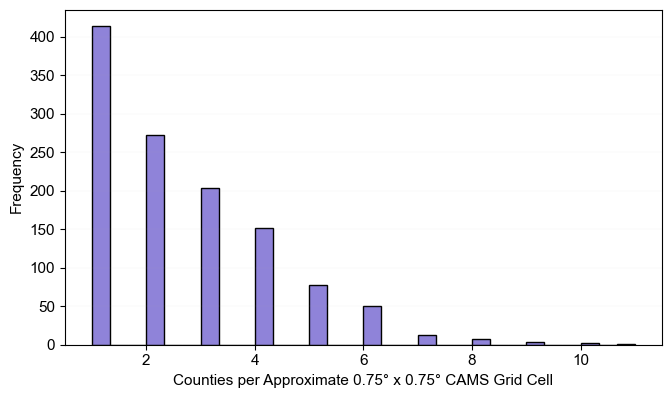

                 Scope  Number of Grid Cells  Mean Counties per Grid Cell  Median Counties per Grid Cell  Max Counties per Grid Cell
    All Study Counties                  1194                     2.563652                            2.0                          11
Held-Out Test Counties                   487                     1.258727                            1.0                           4

Saved CAMS grid summary to: data_cvd/outputs/modeling/xgboost/revision/cams_grid_summary.csv
Saved CAMS grid histogram to: data_cvd/outputs/modeling/xgboost/revision/cams_grid_histogram.png


In [33]:
def summarize_grid_counts(counts_df, scope):
    return {
        'Scope': scope,
        'Number of Grid Cells': int(counts_df.shape[0]),
        'Mean Counties per Grid Cell': float(counts_df['County Count'].mean()),
        'Median Counties per Grid Cell': float(counts_df['County Count'].median()),
        'Max Counties per Grid Cell': int(counts_df['County Count'].max()),
    }

cams_grid_summary = pd.DataFrame([
    summarize_grid_counts(all_grid_counts, 'All Study Counties'),
    summarize_grid_counts(test_grid_counts, 'Held-Out Test Counties'),
])

cams_grid_summary_path = OUTPUT_DIR / 'cams_grid_summary.csv'
cams_grid_summary.to_csv(cams_grid_summary_path, index=False)

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.6))
sns.histplot(all_grid_counts['County Count'], bins=30, color='slateblue', ax=ax)
ax.set_xlabel('Counties per Approximate 0.75° x 0.75° CAMS Grid Cell', fontsize=FONT_SIZE)
ax.set_ylabel('Frequency', fontsize=FONT_SIZE)
ax.grid(axis='y', linewidth=0.15, alpha=0.3)
plt.tight_layout()

cams_grid_histogram_path = OUTPUT_DIR / 'cams_grid_histogram.png'
plt.savefig(cams_grid_histogram_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(cams_grid_summary.to_string(index=False))
print(f'\nSaved CAMS grid summary to: {project_relative_path(cams_grid_summary_path)}')
print(f'Saved CAMS grid histogram to: {project_relative_path(cams_grid_histogram_path)}')


### 13.3 County Polygon Grid Overlap

County polygons are intersected with the same approximate 0.75° grid to estimate how often counties span more than one atmospheric support region.


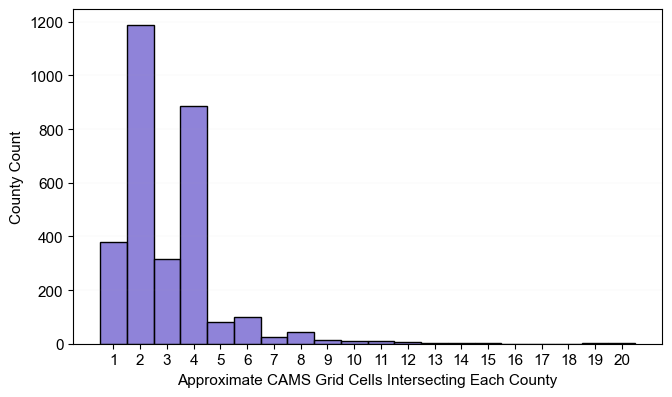

                 Scope  Counties  Single-Cell Counties  Multi-Cell Counties  Percent Multi-Cell  Mean Grid Cells per County  Median Grid Cells per County  Max Grid Cells per County
    All Study Counties      3061                   378                 2683           87.651094                    3.026789                           2.0                         20
Held-Out Test Counties       613                    68                  545           88.907015                    3.138662                           3.0                         15

Saved county grid overlap table to: data_cvd/outputs/modeling/xgboost/revision/cams_county_grid_overlap.csv
Saved county grid overlap summary to: data_cvd/outputs/modeling/xgboost/revision/cams_county_grid_overlap_summary.csv
Saved county grid overlap histogram to: data_cvd/outputs/modeling/xgboost/revision/cams_county_grid_overlap_histogram.png


In [34]:
min_lon, min_lat, max_lon, max_lat = counties.total_bounds
lon_edges = np.arange(np.floor(min_lon / CAMS_GRID_DEGREES) * CAMS_GRID_DEGREES,
                      np.ceil(max_lon / CAMS_GRID_DEGREES) * CAMS_GRID_DEGREES + CAMS_GRID_DEGREES,
                      CAMS_GRID_DEGREES)
lat_edges = np.arange(np.floor(min_lat / CAMS_GRID_DEGREES) * CAMS_GRID_DEGREES,
                      np.ceil(max_lat / CAMS_GRID_DEGREES) * CAMS_GRID_DEGREES + CAMS_GRID_DEGREES,
                      CAMS_GRID_DEGREES)

grid_records = [
    {
        'grid_id': f'{lat:.2f}_{lon:.2f}',
        'grid_lon_min': lon,
        'grid_lat_min': lat,
        'geometry': box(lon, lat, lon + CAMS_GRID_DEGREES, lat + CAMS_GRID_DEGREES),
    }
    for lon in lon_edges[:-1]
    for lat in lat_edges[:-1]
]
cams_grid = gpd.GeoDataFrame(grid_records, crs=4326)

overlap = gpd.overlay(
    counties[[GROUP_COL, 'NAME', 'Scope', 'cams_grid_id', 'geometry']],
    cams_grid,
    how='intersection',
)
overlap['overlap_area_km2'] = overlap.to_crs(5070).area / 1e6
overlap = overlap[overlap['overlap_area_km2'] > 1e-6].copy()

county_area = counties[[GROUP_COL, 'geometry']].to_crs(5070).copy()
county_area['county_area_km2'] = county_area.geometry.area / 1e6
county_area = county_area[[GROUP_COL, 'county_area_km2']]

dominant = overlap.loc[overlap.groupby(GROUP_COL)['overlap_area_km2'].idxmax(), [GROUP_COL, 'grid_id', 'overlap_area_km2']]
dominant = dominant.rename(columns={'grid_id': 'Dominant Grid Cell', 'overlap_area_km2': 'Dominant Cell Area km2'})

county_grid_overlap = (
    overlap.groupby([GROUP_COL, 'NAME', 'Scope', 'cams_grid_id'])
    .agg(Grid_Cell_Count=('grid_id', 'nunique'))
    .reset_index()
    .merge(county_area, on=GROUP_COL, how='left')
    .merge(dominant, on=GROUP_COL, how='left')
)
county_grid_overlap['Dominant Cell Area Share'] = county_grid_overlap['Dominant Cell Area km2'] / county_grid_overlap['county_area_km2']
county_grid_overlap['Spans Multiple Grid Cells'] = county_grid_overlap['Grid_Cell_Count'] > 1
county_grid_overlap = county_grid_overlap.rename(columns={
    GROUP_COL: 'Fips',
    'NAME': 'County Name',
    'cams_grid_id': 'Centroid Grid Cell',
    'county_area_km2': 'County Area km2',
})

county_grid_overlap_path = OUTPUT_DIR / 'cams_county_grid_overlap.csv'
county_grid_overlap.to_csv(county_grid_overlap_path, index=False)

def summarize_overlap(scope_df, scope):
    return {
        'Scope': scope,
        'Counties': int(scope_df.shape[0]),
        'Single-Cell Counties': int((scope_df['Grid_Cell_Count'] == 1).sum()),
        'Multi-Cell Counties': int((scope_df['Grid_Cell_Count'] > 1).sum()),
        'Percent Multi-Cell': float((scope_df['Grid_Cell_Count'] > 1).mean() * 100),
        'Mean Grid Cells per County': float(scope_df['Grid_Cell_Count'].mean()),
        'Median Grid Cells per County': float(scope_df['Grid_Cell_Count'].median()),
        'Max Grid Cells per County': int(scope_df['Grid_Cell_Count'].max()),
    }

all_overlap_summary = summarize_overlap(county_grid_overlap, 'All Study Counties')
test_overlap_summary = summarize_overlap(county_grid_overlap[county_grid_overlap['Fips'].isin(test_fips)], 'Held-Out Test Counties')
county_grid_overlap_summary = pd.DataFrame([all_overlap_summary, test_overlap_summary])
county_grid_overlap_summary_path = OUTPUT_DIR / 'cams_county_grid_overlap_summary.csv'
county_grid_overlap_summary.to_csv(county_grid_overlap_summary_path, index=False)

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.6))
max_cells = int(county_grid_overlap['Grid_Cell_Count'].max())
sns.histplot(county_grid_overlap['Grid_Cell_Count'], bins=np.arange(1, max_cells + 2) - 0.5, color='slateblue', ax=ax)
ax.set_xlabel('Approximate CAMS Grid Cells Intersecting Each County', fontsize=FONT_SIZE)
ax.set_ylabel('County Count', fontsize=FONT_SIZE)
ax.set_xticks(range(1, max_cells + 1))
ax.grid(axis='y', linewidth=0.15, alpha=0.3)
plt.tight_layout()

county_grid_overlap_histogram_path = OUTPUT_DIR / 'cams_county_grid_overlap_histogram.png'
plt.savefig(county_grid_overlap_histogram_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(county_grid_overlap_summary.to_string(index=False))
print(f'\nSaved county grid overlap table to: {project_relative_path(county_grid_overlap_path)}')
print(f'Saved county grid overlap summary to: {project_relative_path(county_grid_overlap_summary_path)}')
print(f'Saved county grid overlap histogram to: {project_relative_path(county_grid_overlap_histogram_path)}')


### 13.4 CAMS Diagnostic Artifact Verification

This cell verifies that all CAMS spatial-resolution diagnostic outputs were written to the revision output directory.


In [35]:
expected_cams_outputs = [
    'cams_centroid_grid_cell_counts.csv',
    'cams_grid_summary.csv',
    'cams_county_grid_overlap.csv',
    'cams_county_grid_overlap_summary.csv',
    'cams_grid_histogram.png',
    'cams_county_grid_overlap_histogram.png',
]
missing_cams_outputs = [name for name in expected_cams_outputs if not (OUTPUT_DIR / name).exists()]
if missing_cams_outputs:
    raise FileNotFoundError('Missing CAMS diagnostic outputs: ' + ', '.join(missing_cams_outputs))

print('CAMS diagnostic artifact check passed:')
for name in expected_cams_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


CAMS diagnostic artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/cams_centroid_grid_cell_counts.csv
- data_cvd/outputs/modeling/xgboost/revision/cams_grid_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/cams_county_grid_overlap.csv
- data_cvd/outputs/modeling/xgboost/revision/cams_county_grid_overlap_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/cams_grid_histogram.png
- data_cvd/outputs/modeling/xgboost/revision/cams_county_grid_overlap_histogram.png


## 14. Formaldehyde-Poverty Stratified SHAP

This section examines whether the formaldehyde contribution learned by the canonical XGBoost model differs across socioeconomic context. It reuses the canonical held-out test set and saved SHAP values; no additional model is fitted.


### 14.1 Build the Formaldehyde SHAP Analysis Table

The canonical SHAP array is aligned with the saved held-out prediction table. The formaldehyde SHAP column is extracted using the original model feature order from the reduced dataset.


In [36]:
IDENTIFIER_COLS = ['County', 'State', 'Year', 'Fips']
shap_values_path = OUTPUT_DIR / 'canonical_shap_values.npy'
test_predictions_path = OUTPUT_DIR / 'canonical_test_predictions.csv'
assert shap_values_path.exists(), f'Missing canonical SHAP values: {project_relative_path(shap_values_path)}'
assert test_predictions_path.exists(), f'Missing canonical test predictions: {project_relative_path(test_predictions_path)}'

canonical_shap_values_for_poverty = np.load(shap_values_path)
canonical_test_for_poverty = pd.read_csv(test_predictions_path)
feature_order_for_shap = pd.read_csv(DATA_PATH, nrows=0).drop(columns=IDENTIFIER_COLS + [TARGET_COL]).columns.tolist()

required_poverty_columns = [
    TARGET_COL,
    'Predicted CVD Mortality Rate',
    'Residual',
    'Poverty Rate',
    "Bachelor's Degree or Higher (%)",
    FORMALDEHYDE_FEATURE,
]
missing_poverty_columns = [col for col in required_poverty_columns if col not in canonical_test_for_poverty.columns]
if missing_poverty_columns:
    raise KeyError(f'Missing required columns in canonical test predictions: {missing_poverty_columns}')
if canonical_shap_values_for_poverty.shape != (canonical_test_for_poverty.shape[0], len(feature_order_for_shap)):
    raise ValueError(
        f'SHAP array shape {canonical_shap_values_for_poverty.shape} does not match '
        f'test rows/features {(canonical_test_for_poverty.shape[0], len(feature_order_for_shap))}.'
    )

formaldehyde_shap_index = feature_order_for_shap.index(FORMALDEHYDE_FEATURE)
formaldehyde_poverty_df = canonical_test_for_poverty[
    IDENTIFIER_COLS + required_poverty_columns
].copy()
formaldehyde_poverty_df['Formaldehyde SHAP Value'] = canonical_shap_values_for_poverty[:, formaldehyde_shap_index]

print(f'Rows in formaldehyde-poverty SHAP table: {formaldehyde_poverty_df.shape[0]:,}')
print(f'Formaldehyde SHAP feature index: {formaldehyde_shap_index}')
print(formaldehyde_poverty_df[[FORMALDEHYDE_FEATURE, 'Poverty Rate', 'Formaldehyde SHAP Value']].describe().to_string())


Rows in formaldehyde-poverty SHAP table: 4,904
Formaldehyde SHAP feature index: 27
       FoT Formaldehyde Above75ᵗʰ Percentile  Poverty Rate  Formaldehyde SHAP Value
count                            4904.000000   4904.000000              4904.000000
mean                               23.486556     16.292088                -0.202126
std                                15.744667      6.518256                11.157365
min                                 0.000000      2.400000               -21.093349
25%                                 9.379089     11.600000                -9.310883
50%                                21.910397     15.300000                -5.889712
75%                                37.465847     19.800000                12.012793
max                                54.075342     49.700000                21.832819


### 14.2 Poverty Quartiles and Stratified SHAP Figure

Held-out observations are split into four poverty strata using rank-first quartiles. Each panel shows formaldehyde exposure frequency against its SHAP contribution within one poverty quartile.


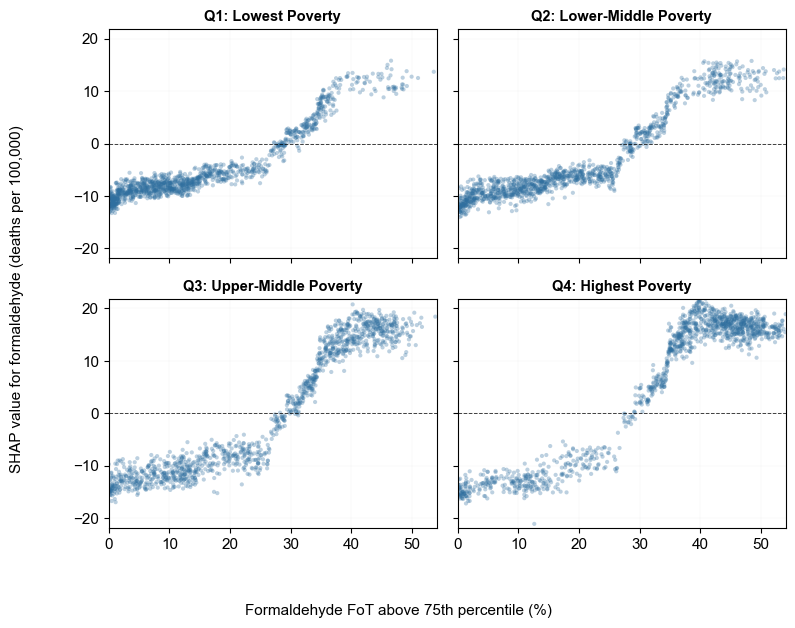

        Poverty Quartile    N  Poverty_Min  Poverty_Median  Poverty_Max  Formaldehyde_Min  Formaldehyde_Median  Formaldehyde_Max  Mean_Formaldehyde_SHAP  Median_Formaldehyde_SHAP  Percent_Positive_Formaldehyde_SHAP  Mean_CVD_Mortality
      Q1: Lowest Poverty 1226          2.4            9.50         11.6          0.000000            12.106726         53.620219               -4.772798                 -7.311990                           20.799347          231.654312
Q2: Lower-Middle Poverty 1226         11.6           13.50         15.3          0.000000            16.752049         53.756831               -3.553681                 -6.804830                           26.508972          258.814966
Q3: Upper-Middle Poverty 1226         15.3           17.30         19.8          0.000000            27.582061         53.869863                0.560056                 -2.543877                           47.471452          281.172004
     Q4: Highest Poverty 1226         19.8           23.55  

In [37]:
poverty_labels = [
    'Q1: Lowest Poverty',
    'Q2: Lower-Middle Poverty',
    'Q3: Upper-Middle Poverty',
    'Q4: Highest Poverty',
]
formaldehyde_poverty_df['Poverty Quartile'] = pd.qcut(
    formaldehyde_poverty_df['Poverty Rate'].rank(method='first'),
    q=4,
    labels=poverty_labels,
)

quartile_summary = (
    formaldehyde_poverty_df
    .groupby('Poverty Quartile', observed=True)
    .agg(
        N=('Poverty Rate', 'size'),
        Poverty_Min=('Poverty Rate', 'min'),
        Poverty_Median=('Poverty Rate', 'median'),
        Poverty_Max=('Poverty Rate', 'max'),
        Formaldehyde_Min=(FORMALDEHYDE_FEATURE, 'min'),
        Formaldehyde_Median=(FORMALDEHYDE_FEATURE, 'median'),
        Formaldehyde_Max=(FORMALDEHYDE_FEATURE, 'max'),
        Mean_Formaldehyde_SHAP=('Formaldehyde SHAP Value', 'mean'),
        Median_Formaldehyde_SHAP=('Formaldehyde SHAP Value', 'median'),
        Percent_Positive_Formaldehyde_SHAP=('Formaldehyde SHAP Value', lambda values: float((values > 0).mean() * 100)),
        Mean_CVD_Mortality=(TARGET_COL, 'mean'),
    )
    .reset_index()
)

formaldehyde_poverty_shap_data_path = OUTPUT_DIR / 'formaldehyde_poverty_shap_data.csv'
formaldehyde_poverty_quartile_summary_path = OUTPUT_DIR / 'formaldehyde_poverty_quartile_summary.csv'
formaldehyde_poverty_df.to_csv(formaldehyde_poverty_shap_data_path, index=False)
quartile_summary.to_csv(formaldehyde_poverty_quartile_summary_path, index=False)

x_min = formaldehyde_poverty_df[FORMALDEHYDE_FEATURE].min()
x_max = formaldehyde_poverty_df[FORMALDEHYDE_FEATURE].max()
y_abs_max = float(np.nanmax(np.abs(formaldehyde_poverty_df['Formaldehyde SHAP Value'])))

fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL_WIDTH * 1.18, DOUBLE_COL_WIDTH * 0.95), sharex=True, sharey=True)
for ax, quartile in zip(axes.flatten(), poverty_labels):
    subset = formaldehyde_poverty_df[formaldehyde_poverty_df['Poverty Quartile'] == quartile]
    ax.scatter(
        subset[FORMALDEHYDE_FEATURE],
        subset['Formaldehyde SHAP Value'],
        alpha=0.32,
        s=9,
        color='#2f6f9f',
        edgecolors='none',
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.75)
    ax.set_title(quartile, fontsize=FONT_SIZE - 0.5, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-y_abs_max, y_abs_max)
    ax.grid(axis='both', linewidth=0.15, alpha=0.3)

fig.supxlabel('Formaldehyde FoT above 75th percentile (%)', fontsize=FONT_SIZE)
fig.supylabel('SHAP value for formaldehyde (deaths per 100,000)', fontsize=FONT_SIZE)
plt.tight_layout(rect=[0.04, 0.04, 1.0, 0.97])

formaldehyde_poverty_quartiles_path = OUTPUT_DIR / 'formaldehyde_poverty_quartiles.png'
plt.savefig(formaldehyde_poverty_quartiles_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(quartile_summary.to_string(index=False))
print(f'\nSaved formaldehyde-poverty SHAP data to: {project_relative_path(formaldehyde_poverty_shap_data_path)}')
print(f'Saved quartile summary to: {project_relative_path(formaldehyde_poverty_quartile_summary_path)}')
print(f'Saved quartile figure to: {project_relative_path(formaldehyde_poverty_quartiles_path)}')


### 14.3 Partial Correlation After Socioeconomic Residualization

As a numeric sensitivity check, formaldehyde exposure and CVD mortality are residualized on poverty and educational attainment. Pearson correlations are computed for county-year observations and county means.


In [38]:
from scipy.stats import pearsonr

partial_control_vars = ['Poverty Rate', "Bachelor's Degree or Higher (%)"]


def residualize_on_controls(values, controls):
    design = np.column_stack([np.ones(len(controls)), controls.to_numpy(dtype=float)])
    coefficients = np.linalg.lstsq(design, values.to_numpy(dtype=float), rcond=None)[0]
    return values.to_numpy(dtype=float) - design @ coefficients


def compute_partial_correlation(data, analysis_level):
    complete = data[[FORMALDEHYDE_FEATURE, TARGET_COL] + partial_control_vars].dropna().copy()
    residual_formaldehyde = residualize_on_controls(complete[FORMALDEHYDE_FEATURE], complete[partial_control_vars])
    residual_cvd = residualize_on_controls(complete[TARGET_COL], complete[partial_control_vars])
    partial_corr, p_value = pearsonr(residual_formaldehyde, residual_cvd)
    return {
        'Analysis Level': analysis_level,
        'Exposure Variable': FORMALDEHYDE_FEATURE,
        'Outcome Variable': TARGET_COL,
        'Controls': '; '.join(partial_control_vars),
        'Partial Correlation': float(partial_corr),
        'P-value': float(p_value),
        'N': int(len(complete)),
    }

county_mean_formaldehyde_poverty_df = (
    formaldehyde_poverty_df
    .groupby(GROUP_COL, as_index=False)[[FORMALDEHYDE_FEATURE, TARGET_COL] + partial_control_vars]
    .mean()
)

partial_correlation_df = pd.DataFrame([
    compute_partial_correlation(formaldehyde_poverty_df, 'County-year observations'),
    compute_partial_correlation(county_mean_formaldehyde_poverty_df, 'County means'),
])

formaldehyde_partial_correlation_path = OUTPUT_DIR / 'formaldehyde_partial_correlation.csv'
partial_correlation_df.to_csv(formaldehyde_partial_correlation_path, index=False)

for _, row in partial_correlation_df.iterrows():
    print(
        f"{row['Analysis Level']}: partial correlation = {row['Partial Correlation']:.4f}, "
        f"p = {row['P-value']:.4e}, N = {int(row['N'])}"
    )
print(f'\nSaved partial correlation table to: {project_relative_path(formaldehyde_partial_correlation_path)}')


County-year observations: partial correlation = 0.4735, p = 1.3098e-272, N = 4904
County means: partial correlation = 0.4766, p = 4.3400e-36, N = 613

Saved partial correlation table to: data_cvd/outputs/modeling/xgboost/revision/formaldehyde_partial_correlation.csv


### 14.4 Formaldehyde-Poverty Artifact Verification

This cell verifies that the formaldehyde-poverty SHAP outputs were written to the revision output directory.


In [39]:
expected_formaldehyde_poverty_outputs = [
    'formaldehyde_poverty_shap_data.csv',
    'formaldehyde_poverty_quartile_summary.csv',
    'formaldehyde_partial_correlation.csv',
    'formaldehyde_poverty_quartiles.png',
]
missing_formaldehyde_poverty_outputs = [
    name for name in expected_formaldehyde_poverty_outputs
    if not (OUTPUT_DIR / name).exists()
]
if missing_formaldehyde_poverty_outputs:
    raise FileNotFoundError(
        'Missing formaldehyde-poverty outputs: ' + ', '.join(missing_formaldehyde_poverty_outputs)
    )

print('Formaldehyde-poverty SHAP artifact check passed:')
for name in expected_formaldehyde_poverty_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Formaldehyde-poverty SHAP artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/formaldehyde_poverty_shap_data.csv
- data_cvd/outputs/modeling/xgboost/revision/formaldehyde_poverty_quartile_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/formaldehyde_partial_correlation.csv
- data_cvd/outputs/modeling/xgboost/revision/formaldehyde_poverty_quartiles.png


## 15. Temporal Validation

This section evaluates whether the fixed-parameter XGBoost model generalizes forward in time. The model is trained on 2012-2016 county-year observations and evaluated on 2017-2019 observations using the same 43-predictor schema as the canonical model.


### 15.1 Temporal Train-Test Partition

The reduced CVD dataset is split by calendar year rather than by county. This directly tests forward-period prediction while preserving the canonical feature schema and target scaling.


In [40]:
temporal_train_years = list(range(2012, 2017))
temporal_test_years = list(range(2017, 2020))

temporal_df = pd.read_csv(DATA_PATH)
if temporal_df[TARGET_COL].max() > 1:
    raise ValueError(f'{TARGET_COL} appears already scaled; do not multiply again.')
temporal_df[TARGET_COL] = temporal_df[TARGET_COL] * 100000

X_temporal, y_temporal, _ = prepare_features_and_target(temporal_df)
train_temporal_mask = temporal_df[YEAR_COL].isin(temporal_train_years)
test_temporal_mask = temporal_df[YEAR_COL].isin(temporal_test_years)

X_temporal_train = X_temporal.loc[train_temporal_mask].copy()
X_temporal_test = X_temporal.loc[test_temporal_mask].copy()
y_temporal_train = y_temporal.loc[train_temporal_mask].copy()
y_temporal_test = y_temporal.loc[test_temporal_mask].copy()
df_temporal_train = temporal_df.loc[train_temporal_mask].copy()
df_temporal_test = temporal_df.loc[test_temporal_mask].copy()

if X_temporal_train.empty or X_temporal_test.empty:
    raise ValueError('Temporal train/test split produced an empty partition.')
if set(df_temporal_train[YEAR_COL]).intersection(set(df_temporal_test[YEAR_COL])):
    raise ValueError('Temporal train and test years overlap.')

print(f'Temporal training years: {temporal_train_years}')
print(f'Temporal test years: {temporal_test_years}')
print(f'Train rows: {X_temporal_train.shape[0]:,}; test rows: {X_temporal_test.shape[0]:,}')
print(f'Train counties: {df_temporal_train[GROUP_COL].nunique():,}; test counties: {df_temporal_test[GROUP_COL].nunique():,}')
print(f'Predictors: {X_temporal_train.shape[1]}')


Temporal training years: [2012, 2013, 2014, 2015, 2016]
Temporal test years: [2017, 2018, 2019]
Train rows: 15,305; test rows: 9,182
Train counties: 3,061; test counties: 3,061
Predictors: 43


### 15.2 Fixed-Parameter Temporal Model

A new XGBoost model is fitted only for this temporal validation task using the fixed Table 2 hyperparameters.


In [41]:
temporal_model = xgb.XGBRegressor(**CVD_HYPERPARAMETERS)
temporal_model.fit(X_temporal_train, y_temporal_train)

temporal_train_predictions = temporal_model.predict(X_temporal_train)
temporal_test_predictions = temporal_model.predict(X_temporal_test)

temporal_metrics_df = evaluate_model(
    y_temporal_train,
    temporal_train_predictions,
    y_temporal_test,
    temporal_test_predictions,
    X_temporal_train.shape[1],
)

temporal_metrics_path = OUTPUT_DIR / 'temporal_metrics.csv'
temporal_metrics_df.to_csv(temporal_metrics_path, index=False)

print('Temporal validation metrics')
print(temporal_metrics_df.to_string(index=False))
print(f'\nSaved temporal metrics to: {project_relative_path(temporal_metrics_path)}')


Temporal validation metrics
            Metric  Training Set    Test Set
          R² Score      0.911006    0.788393
       Adjusted R²      0.910755    0.787397
RMSE (per 100,000)     16.293814   25.340743
 MAE (per 100,000)     12.369342   18.985050
       Sample Size  15305.000000 9182.000000

Saved temporal metrics to: data_cvd/outputs/modeling/xgboost/revision/temporal_metrics.csv


### 15.3 Temporal Prediction Table and Scatter Plot

Held-out 2017-2019 predictions are saved with residuals, and a temporal observed-versus-predicted scatter plot is generated.


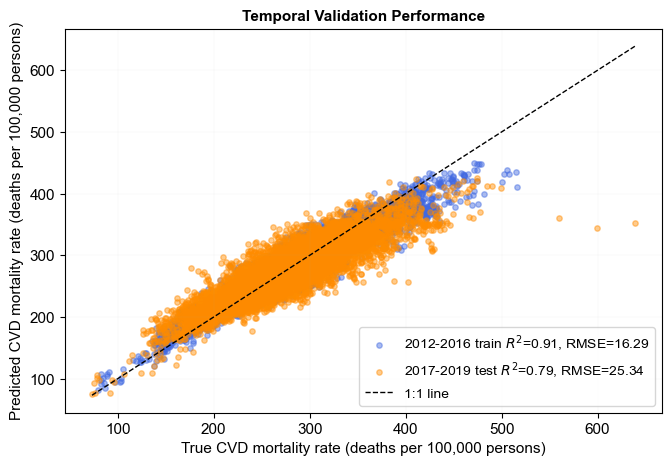

Saved temporal predictions to: data_cvd/outputs/modeling/xgboost/revision/temporal_test_predictions.csv
Saved temporal scatter plot to: data_cvd/outputs/modeling/xgboost/revision/temporal_scatter_performance.png


In [42]:
temporal_predictions_path = OUTPUT_DIR / 'temporal_test_predictions.csv'
temporal_predictions_df = save_prediction_table(
    df_temporal_test,
    y_temporal_test,
    temporal_test_predictions,
    temporal_predictions_path,
)

def save_temporal_scatter(y_train, train_predictions, y_test, test_predictions, output_path):
    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))
    ax.scatter(
        y_train,
        train_predictions,
        color='royalblue',
        alpha=0.45,
        s=15,
        label=f'2012-2016 train $R^2$={r2_score(y_train, train_predictions):.2f}, RMSE={rmse_score(y_train, train_predictions):.2f}',
    )
    ax.scatter(
        y_test,
        test_predictions,
        color='darkorange',
        alpha=0.45,
        s=15,
        label=f'2017-2019 test $R^2$={r2_score(y_test, test_predictions):.2f}, RMSE={rmse_score(y_test, test_predictions):.2f}',
    )
    lower = min(np.min(y_train), np.min(y_test))
    upper = max(np.max(y_train), np.max(y_test))
    ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1, label='1:1 line')
    ax.set_xlabel('True CVD mortality rate (deaths per 100,000 persons)', fontsize=FONT_SIZE)
    ax.set_ylabel('Predicted CVD mortality rate (deaths per 100,000 persons)', fontsize=FONT_SIZE)
    ax.set_title('Temporal Validation Performance', fontsize=FONT_SIZE, fontweight='bold')
    ax.legend(fontsize=10, frameon=True, loc='lower right')
    ax.grid(axis='both', linewidth=0.15, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    plt.show()


temporal_scatter_path = OUTPUT_DIR / 'temporal_scatter_performance.png'
save_temporal_scatter(
    y_temporal_train,
    temporal_train_predictions,
    y_temporal_test,
    temporal_test_predictions,
    temporal_scatter_path,
)

print(f'Saved temporal predictions to: {project_relative_path(temporal_predictions_path)}')
print(f'Saved temporal scatter plot to: {project_relative_path(temporal_scatter_path)}')


### 15.4 Temporal Validation Artifact Verification

This cell verifies that all temporal validation outputs were written to the revision output directory.


In [43]:
expected_temporal_outputs = [
    'temporal_metrics.csv',
    'temporal_test_predictions.csv',
    'temporal_scatter_performance.png',
]
missing_temporal_outputs = [name for name in expected_temporal_outputs if not (OUTPUT_DIR / name).exists()]
if missing_temporal_outputs:
    raise FileNotFoundError('Missing temporal validation outputs: ' + ', '.join(missing_temporal_outputs))

print('Temporal validation artifact check passed:')
for name in expected_temporal_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Temporal validation artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/temporal_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/temporal_test_predictions.csv
- data_cvd/outputs/modeling/xgboost/revision/temporal_scatter_performance.png


## 16. SHAP Ranking Stability Across GroupKFold Folds

This section evaluates whether formaldehyde remains highly ranked when the fixed-parameter XGBoost model is refit across five county-grouped validation folds. Each fold excludes a disjoint set of counties from training.


### 16.1 Fold-Level SHAP Stability Loop

A fixed-parameter model is trained in each `GroupKFold` split. SHAP values are computed on the held-out fold, features are ranked by mean absolute SHAP value, and the formaldehyde rank is recorded.


In [44]:
from sklearn.model_selection import GroupKFold

stability_df_raw = pd.read_csv(DATA_PATH)
if stability_df_raw[TARGET_COL].max() > 1:
    raise ValueError(f'{TARGET_COL} appears already scaled; do not multiply again.')
stability_df_raw[TARGET_COL] = stability_df_raw[TARGET_COL] * 100000

X_stability, y_stability, groups_stability = prepare_features_and_target(stability_df_raw)
if FORMALDEHYDE_FEATURE not in X_stability.columns:
    raise KeyError(f'Missing formaldehyde feature: {FORMALDEHYDE_FEATURE}')

stability_records = []
gkf = GroupKFold(n_splits=5)

for fold, (train_idx_fold, val_idx_fold) in enumerate(gkf.split(X_stability, y_stability, groups=groups_stability), start=1):
    X_fold_train = X_stability.iloc[train_idx_fold].copy()
    X_fold_val = X_stability.iloc[val_idx_fold].copy()
    y_fold_train = y_stability.iloc[train_idx_fold].copy()
    y_fold_val = y_stability.iloc[val_idx_fold].copy()
    groups_fold_train = groups_stability.iloc[train_idx_fold]
    groups_fold_val = groups_stability.iloc[val_idx_fold]

    fold_model = xgb.XGBRegressor(**CVD_HYPERPARAMETERS)
    fold_model.fit(X_fold_train, y_fold_train)
    fold_val_predictions = fold_model.predict(X_fold_val)

    fold_explainer = shap.TreeExplainer(fold_model)
    try:
        fold_shap_values = fold_explainer.shap_values(X_fold_val, check_additivity=False)
    except TypeError:
        fold_shap_values = fold_explainer.shap_values(X_fold_val)
    if isinstance(fold_shap_values, list):
        fold_shap_values = fold_shap_values[0]
    if hasattr(fold_shap_values, 'values'):
        fold_shap_values = fold_shap_values.values
    fold_shap_values = np.asarray(fold_shap_values)

    fold_ranking = (
        pd.DataFrame({
            'Feature': X_fold_val.columns,
            'Mean |SHAP|': np.abs(fold_shap_values).mean(axis=0),
        })
        .sort_values('Mean |SHAP|', ascending=False)
        .reset_index(drop=True)
    )
    fold_ranking['Rank'] = np.arange(1, fold_ranking.shape[0] + 1)

    formaldehyde_row = fold_ranking.loc[fold_ranking['Feature'] == FORMALDEHYDE_FEATURE].iloc[0]
    top_10_features = fold_ranking['Feature'].head(10).tolist()

    stability_records.append({
        'Fold': fold,
        'Training Rows': len(X_fold_train),
        'Validation Rows': len(X_fold_val),
        'Training Counties': int(groups_fold_train.nunique()),
        'Validation Counties': int(groups_fold_val.nunique()),
        'Validation R²': float(r2_score(y_fold_val, fold_val_predictions)),
        'Validation RMSE': float(rmse_score(y_fold_val, fold_val_predictions)),
        'Validation MAE': float(mean_absolute_error(y_fold_val, fold_val_predictions)),
        'Formaldehyde Rank': int(formaldehyde_row['Rank']),
        'Formaldehyde Mean |SHAP|': float(formaldehyde_row['Mean |SHAP|']),
        'Top 10 Features': ' | '.join(clean_display_labels(top_10_features)),
    })
    print(f"Fold {fold}: formaldehyde rank {int(formaldehyde_row['Rank'])}; validation R²={r2_score(y_fold_val, fold_val_predictions):.3f}")

shap_stability_fold_ranks = pd.DataFrame(stability_records)
shap_stability_fold_ranks_path = OUTPUT_DIR / 'shap_stability_fold_ranks.csv'
shap_stability_fold_ranks.to_csv(shap_stability_fold_ranks_path, index=False)

print(f'\nSaved SHAP stability fold ranks to: {project_relative_path(shap_stability_fold_ranks_path)}')
print(shap_stability_fold_ranks.to_string(index=False))


Fold 1: formaldehyde rank 2; validation R²=0.684
Fold 2: formaldehyde rank 2; validation R²=0.706
Fold 3: formaldehyde rank 2; validation R²=0.716
Fold 4: formaldehyde rank 2; validation R²=0.755
Fold 5: formaldehyde rank 2; validation R²=0.685

Saved SHAP stability fold ranks to: data_cvd/outputs/modeling/xgboost/revision/shap_stability_fold_ranks.csv
 Fold  Training Rows  Validation Rows  Training Counties  Validation Counties  Validation R²  Validation RMSE  Validation MAE  Formaldehyde Rank  Formaldehyde Mean |SHAP|                                                                                                                                                                                                                                                                              Top 10 Features
    1          19584             4903               2448                  613       0.683593        30.193637       22.192001                  2                 11.000147                 Ba

### 16.2 SHAP Stability Summary

The fold-level ranks are summarized to report the range and central tendency of the formaldehyde rank across county-grouped validation folds.


In [45]:
shap_stability_summary = pd.DataFrame([{
    'Folds': int(shap_stability_fold_ranks.shape[0]),
    'Mean Formaldehyde Rank': float(shap_stability_fold_ranks['Formaldehyde Rank'].mean()),
    'Median Formaldehyde Rank': float(shap_stability_fold_ranks['Formaldehyde Rank'].median()),
    'Min Formaldehyde Rank': int(shap_stability_fold_ranks['Formaldehyde Rank'].min()),
    'Max Formaldehyde Rank': int(shap_stability_fold_ranks['Formaldehyde Rank'].max()),
    'Folds Formaldehyde Top 3': int((shap_stability_fold_ranks['Formaldehyde Rank'] <= 3).sum()),
    'Folds Formaldehyde Top 5': int((shap_stability_fold_ranks['Formaldehyde Rank'] <= 5).sum()),
    'Mean Validation R²': float(shap_stability_fold_ranks['Validation R²'].mean()),
    'Mean Validation RMSE': float(shap_stability_fold_ranks['Validation RMSE'].mean()),
    'Mean Validation MAE': float(shap_stability_fold_ranks['Validation MAE'].mean()),
}])

shap_stability_summary_path = OUTPUT_DIR / 'shap_stability_summary.csv'
shap_stability_summary.to_csv(shap_stability_summary_path, index=False)

print('SHAP stability summary')
print(shap_stability_summary.to_string(index=False))
print(f'\nSaved SHAP stability summary to: {project_relative_path(shap_stability_summary_path)}')


SHAP stability summary
 Folds  Mean Formaldehyde Rank  Median Formaldehyde Rank  Min Formaldehyde Rank  Max Formaldehyde Rank  Folds Formaldehyde Top 3  Folds Formaldehyde Top 5  Mean Validation R²  Mean Validation RMSE  Mean Validation MAE
     5                     2.0                       2.0                      2                      2                         5                         5            0.709249             29.507398            22.101742

Saved SHAP stability summary to: data_cvd/outputs/modeling/xgboost/revision/shap_stability_summary.csv


### 16.3 SHAP Stability Artifact Verification

This cell verifies that the SHAP stability outputs were written to the revision output directory.


In [46]:
expected_shap_stability_outputs = [
    'shap_stability_fold_ranks.csv',
    'shap_stability_summary.csv',
]
missing_shap_stability_outputs = [
    name for name in expected_shap_stability_outputs
    if not (OUTPUT_DIR / name).exists()
]
if missing_shap_stability_outputs:
    raise FileNotFoundError('Missing SHAP stability outputs: ' + ', '.join(missing_shap_stability_outputs))

print('SHAP stability artifact check passed:')
for name in expected_shap_stability_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')

SHAP stability artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/shap_stability_fold_ranks.csv
- data_cvd/outputs/modeling/xgboost/revision/shap_stability_summary.csv


## 17. Moran's I Spatial Residual Autocorrelation

This section tests whether canonical held-out county residuals retain spatial autocorrelation after model prediction. Residuals are averaged by county and evaluated using K-nearest-neighbor spatial weights among held-out county centroids.


### 17.1 County-Level Mean Residuals

Canonical held-out residuals are aggregated from county-year rows to county-level means and joined to county geometry.


In [47]:
import importlib.util
from matplotlib.colors import TwoSlopeNorm

spatial_dependencies = {
    'geopandas': 'geopandas',
    'libpysal': 'libpysal',
    'esda': 'esda',
}
missing_spatial_dependencies = [name for module, name in spatial_dependencies.items() if importlib.util.find_spec(module) is None]
if missing_spatial_dependencies:
    raise ModuleNotFoundError(
        'Missing spatial-analysis dependencies: ' + ', '.join(missing_spatial_dependencies) +
        '. Install them before running the Moran spatial residual diagnostic.'
    )

import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran

MORAN_K = 8
COUNTY_SHP_PATH = Path('/Users/samyakshrestha/Projects/Life Expectancy Project/data/shapefiles/cb_2019_us_county_20m.shp')
assert COUNTY_SHP_PATH.exists(), f'Missing county shapefile: {COUNTY_SHP_PATH.name}'

canonical_test_residuals = pd.read_csv(OUTPUT_DIR / 'canonical_test_predictions.csv')
required_spatial_cols = [GROUP_COL, 'County', 'State', TARGET_COL, 'Predicted CVD Mortality Rate', 'Residual']
missing_spatial_cols = [col for col in required_spatial_cols if col not in canonical_test_residuals.columns]
if missing_spatial_cols:
    raise KeyError(f'Missing required canonical prediction columns: {missing_spatial_cols}')

canonical_test_residuals['FIPS'] = canonical_test_residuals[GROUP_COL].astype(int).astype(str).str.zfill(5)
county_residuals = (
    canonical_test_residuals
    .groupby('FIPS', as_index=False)
    .agg(
        County=('County', 'first'),
        State=('State', 'first'),
        Test_Observations=('Residual', 'size'),
        Mean_CVD_Mortality=(TARGET_COL, 'mean'),
        Mean_Predicted_CVD_Mortality=('Predicted CVD Mortality Rate', 'mean'),
        Mean_Residual=('Residual', 'mean'),
    )
)

counties_for_spatial = gpd.read_file(COUNTY_SHP_PATH)
if 'GEOID' in counties_for_spatial.columns:
    counties_for_spatial['FIPS'] = counties_for_spatial['GEOID'].astype(str).str.zfill(5)
elif {'STATEFP', 'COUNTYFP'}.issubset(counties_for_spatial.columns):
    counties_for_spatial['FIPS'] = counties_for_spatial['STATEFP'].astype(str).str.zfill(2) + counties_for_spatial['COUNTYFP'].astype(str).str.zfill(3)
else:
    raise ValueError('Could not determine county FIPS column from shapefile.')

spatial_residuals_gdf = counties_for_spatial.merge(county_residuals, on='FIPS', how='inner').copy()
if spatial_residuals_gdf['FIPS'].nunique() != county_residuals['FIPS'].nunique():
    missing_fips = sorted(set(county_residuals['FIPS']) - set(spatial_residuals_gdf['FIPS']))
    raise ValueError(f'County residuals missing from shapefile merge: {missing_fips[:10]}')

spatial_mean_residuals = county_residuals.rename(columns={'FIPS': 'Fips'})
spatial_mean_residuals_by_county_path = OUTPUT_DIR / 'spatial_mean_residuals_by_county.csv'
spatial_mean_residuals.to_csv(spatial_mean_residuals_by_county_path, index=False)

print(f'Held-out counties with mean residuals: {spatial_mean_residuals.shape[0]:,}')
print(f'Mean residual range: {spatial_mean_residuals["Mean_Residual"].min():.2f} to {spatial_mean_residuals["Mean_Residual"].max():.2f} deaths per 100,000')
print(f'Saved county mean residuals to: {project_relative_path(spatial_mean_residuals_by_county_path)}')


Held-out counties with mean residuals: 613
Mean residual range: -68.27 to 153.95 deaths per 100,000
Saved county mean residuals to: data_cvd/outputs/modeling/xgboost/revision/spatial_mean_residuals_by_county.csv


### 17.2 Moran's I with KNN Weights

KNN weights are constructed from projected county centroids using `k=8`, then Moran's I is computed for county-level mean residuals.


In [48]:
spatial_residuals_projected = spatial_residuals_gdf.to_crs(5070).copy()
centroids = spatial_residuals_projected.geometry.centroid
knn_coordinates = np.column_stack([centroids.x, centroids.y])

weights = KNN.from_array(knn_coordinates, k=MORAN_K, ids=spatial_residuals_gdf['FIPS'].tolist())
weights.transform = 'r'

np.random.seed(42)
moran_result = Moran(spatial_residuals_gdf['Mean_Residual'].to_numpy(), weights, permutations=999)

spatial_morans_i = pd.DataFrame([{
    'Moran I': float(moran_result.I),
    'Expected I': float(moran_result.EI),
    'Z-score': float(moran_result.z_norm),
    'P-value': float(moran_result.p_norm),
    'Permutation P-value': float(moran_result.p_sim),
    'N Counties': int(spatial_residuals_gdf.shape[0]),
    'Spatial Weights': f'KNN (k={MORAN_K})',
    'Permutations': 999,
}])

spatial_morans_i_path = OUTPUT_DIR / 'spatial_morans_i.csv'
spatial_morans_i.to_csv(spatial_morans_i_path, index=False)

print(spatial_morans_i.to_string(index=False))
print(f'\nSaved Moran\'s I summary to: {project_relative_path(spatial_morans_i_path)}')


 Moran I  Expected I  Z-score  P-value  Permutation P-value  N Counties Spatial Weights  Permutations
0.061291   -0.001634 3.299296 0.000969                0.001         613       KNN (k=8)           999

Saved Moran's I summary to: data_cvd/outputs/modeling/xgboost/revision/spatial_morans_i.csv


### 17.3 Mean Residual Map

The held-out county mean residuals are mapped with a zero-centered diverging color scale.


In [ ]:
def add_residual_map_north_arrow(ax, x=0.075, y=0.88):
    ax.annotate(
        '', xy=(x, y), xytext=(x, y - 0.085), xycoords='axes fraction',
        arrowprops={'arrowstyle': '-|>', 'lw': 1.4, 'color': 'black', 'mutation_scale': 12},
        zorder=10,
    )
    ax.text(x, y + 0.025, 'N', transform=ax.transAxes, ha='center', va='center', fontsize=FONT_SIZE, fontweight='bold')


def add_residual_map_scale_bar(ax, length_km=500, x_frac=0.075, y_frac=0.085):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x0 = x_min + (x_max - x_min) * x_frac
    y0 = y_min + (y_max - y_min) * y_frac
    length_m = length_km * 1000
    tick_height = (y_max - y_min) * 0.012
    text_pad = (y_max - y_min) * 0.02
    ax.plot([x0, x0 + length_m], [y0, y0], color='black', linewidth=1.8, solid_capstyle='butt', zorder=10)
    ax.plot([x0, x0], [y0 - tick_height, y0 + tick_height], color='black', linewidth=1.2, zorder=10)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick_height, y0 + tick_height], color='black', linewidth=1.2, zorder=10)
    ax.text(x0 + length_m / 2, y0 + text_pad, f'{length_km} km', ha='center', va='bottom', fontsize=FONT_SIZE - 2, zorder=10)


study_fips_for_map = pd.read_csv(DATA_PATH, usecols=[GROUP_COL])[GROUP_COL].astype(int).astype(str).str.zfill(5).unique()
plot_base_gdf = counties_for_spatial[counties_for_spatial['FIPS'].isin(study_fips_for_map)].to_crs(5070).copy()
plot_residuals_gdf = spatial_residuals_gdf.to_crs(5070)

max_abs_residual = float(np.nanmax(np.abs(plot_residuals_gdf['Mean_Residual'])))
residual_norm = TwoSlopeNorm(vmin=-max_abs_residual, vcenter=0, vmax=max_abs_residual)

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.75))
plot_base_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0', linewidth=0.08)
plot_residuals_gdf.plot(
    column='Mean_Residual',
    cmap='coolwarm',
    norm=residual_norm,
    linewidth=0.04,
    edgecolor='#f7f7f7',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Mean residual (deaths per 100,000)', 'shrink': 0.70},
)
colorbar_ax = fig.axes[-1]
colorbar_ax.tick_params(labelsize=FONT_SIZE - 1)
colorbar_ax.set_ylabel('Mean residual (deaths per 100,000)', fontsize=FONT_SIZE - 1)
add_residual_map_north_arrow(ax)
add_residual_map_scale_bar(ax)
ax.set_axis_off()
plt.tight_layout()

spatial_mean_residual_map_path = OUTPUT_DIR / 'spatial_mean_residual_map.png'
plt.savefig(spatial_mean_residual_map_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(f'Saved spatial residual map to: {project_relative_path(spatial_mean_residual_map_path)}')




### 17.4 Spatial Residual Artifact Verification

This cell verifies that the spatial residual outputs were written to the revision output directory.


In [50]:
expected_spatial_outputs = [
    'spatial_mean_residuals_by_county.csv',
    'spatial_morans_i.csv',
    'spatial_mean_residual_map.png',
]
missing_spatial_outputs = [name for name in expected_spatial_outputs if not (OUTPUT_DIR / name).exists()]
if missing_spatial_outputs:
    raise FileNotFoundError('Missing spatial residual outputs: ' + ', '.join(missing_spatial_outputs))

print('Spatial residual artifact check passed:')
for name in expected_spatial_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Spatial residual artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/spatial_mean_residuals_by_county.csv
- data_cvd/outputs/modeling/xgboost/revision/spatial_morans_i.csv
- data_cvd/outputs/modeling/xgboost/revision/spatial_mean_residual_map.png


## 18. Livestock Sensitivity Analysis

This section evaluates whether livestock-density predictors materially influence held-out model performance or the SHAP ranking of formaldehyde. The sensitivity model uses the same county-grouped train-test split and the same fixed XGBoost hyperparameters as the canonical model, with livestock predictors removed before fitting.


### 18.1 No-Livestock Feature Matrices

The livestock predictors are removed from the canonical training and test matrices while preserving the original county split.


In [54]:
LIVESTOCK_FEATURES = ['Cattle', 'Chicken', 'Duck', 'Goat', 'Horse', 'Pig', 'Sheep']

missing_livestock_features = [feature for feature in LIVESTOCK_FEATURES if feature not in X_train.columns]
if missing_livestock_features:
    raise KeyError(f'Missing livestock features in canonical predictor matrix: {missing_livestock_features}')

X_train_no_livestock = X_train.drop(columns=LIVESTOCK_FEATURES).copy()
X_test_no_livestock = X_test.drop(columns=LIVESTOCK_FEATURES).copy()

print(f'Canonical feature count: {X_train.shape[1]}')
print(f'No-livestock feature count: {X_train_no_livestock.shape[1]}')
print('Removed livestock predictors:')
for feature in LIVESTOCK_FEATURES:
    print(f'- {feature}')


Canonical feature count: 43
No-livestock feature count: 36
Removed livestock predictors:
- Cattle
- Chicken
- Duck
- Goat
- Horse
- Pig
- Sheep


### 18.2 Fixed-Parameter No-Livestock Model

A second XGBoost model is fit after removing livestock predictors. All other modeling choices are held constant so the comparison isolates the effect of excluding the livestock-density variables.


In [55]:
livestock_sensitivity_model = build_canonical_model()
livestock_sensitivity_model.fit(X_train_no_livestock, y_train)

livestock_train_pred = livestock_sensitivity_model.predict(X_train_no_livestock)
livestock_test_pred = livestock_sensitivity_model.predict(X_test_no_livestock)

livestock_model_metrics_df = evaluate_model(
    y_train,
    livestock_train_pred,
    y_test,
    livestock_test_pred,
    n_features=X_train_no_livestock.shape[1],
)

print(livestock_model_metrics_df.to_string(index=False))


            Metric  Training Set    Test Set
          R² Score      0.901320    0.703543
       Adjusted R²      0.901139    0.701350
RMSE (per 100,000)     17.259846   29.687466
 MAE (per 100,000)     12.999550   22.222925
       Sample Size  19583.000000 4904.000000


### 18.3 No-Livestock SHAP Ranking

SHAP values are computed for the no-livestock model on the held-out test counties. The resulting ranking is used to check whether formaldehyde remains a leading predictor when livestock-density variables are excluded.


In [56]:
livestock_explainer = shap.TreeExplainer(livestock_sensitivity_model)
livestock_shap_values = livestock_explainer.shap_values(X_test_no_livestock)
if isinstance(livestock_shap_values, list):
    livestock_shap_values = livestock_shap_values[0]
livestock_shap_values = np.array(livestock_shap_values)

livestock_shap_values_path = OUTPUT_DIR / 'livestock_sensitivity_shap_values.npy'
np.save(livestock_shap_values_path, livestock_shap_values)

livestock_shap_ranking_df = pd.DataFrame({
    'Feature': X_test_no_livestock.columns,
    'Display Feature': clean_display_labels(X_test_no_livestock.columns),
    'Mean |SHAP|': np.abs(livestock_shap_values).mean(axis=0),
}).sort_values(by='Mean |SHAP|', ascending=False).reset_index(drop=True)
livestock_shap_ranking_df['Rank'] = np.arange(1, len(livestock_shap_ranking_df) + 1)

livestock_shap_ranking_path = OUTPUT_DIR / 'livestock_sensitivity_shap_ranking.csv'
livestock_shap_ranking_df.to_csv(livestock_shap_ranking_path, index=False)

livestock_formaldehyde_rank = livestock_shap_ranking_df.loc[
    livestock_shap_ranking_df['Feature'] == FORMALDEHYDE_FEATURE,
    'Rank',
]
if livestock_formaldehyde_rank.empty:
    raise KeyError(f'{FORMALDEHYDE_FEATURE} was not found in the no-livestock SHAP ranking.')
livestock_formaldehyde_rank = int(livestock_formaldehyde_rank.iloc[0])

print(livestock_shap_ranking_df.head(10).to_string(index=False))
print()
print(f'No-livestock formaldehyde SHAP rank: {livestock_formaldehyde_rank}')
print(f'Saved no-livestock SHAP ranking to: {project_relative_path(livestock_shap_ranking_path)}')
print(f'Saved no-livestock SHAP values to: {project_relative_path(livestock_shap_values_path)}')


                              Feature                       Display Feature  Mean |SHAP|  Rank
      Bachelor's Degree or Higher (%)       Bachelor's Degree or Higher (%)    13.892067     1
FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile    11.852180     2
                 Wet Bulb Temperature                  Wet Bulb Temperature     8.767561     3
                         Poverty Rate                          Poverty Rate     8.171742     4
              Hispanic Population (%)               Hispanic Population (%)     4.554324     5
           Single Mother Families (%)            Single Mother Families (%)     3.957308     6
     Leaf Area Index, High Vegetation      Leaf Area Index, High Vegetation     3.413401     7
                      Disability Rate                       Disability Rate     2.977491     8
                     Total Population                      Total Population     2.892769     9
     FoT Propane Above75ᵗʰ Percentile      FoT Pro

### 18.4 Canonical-versus-No-Livestock Comparison

The canonical model metrics and SHAP ranking are read from disk, then compared with the no-livestock sensitivity model.


In [57]:
canonical_metrics_for_livestock = pd.read_csv(OUTPUT_DIR / 'canonical_model_metrics.csv')
canonical_shap_for_livestock = pd.read_csv(OUTPUT_DIR / 'canonical_shap_ranking.csv')


def canonical_test_metric(metric_name):
    match = canonical_metrics_for_livestock.loc[
        canonical_metrics_for_livestock['Metric'] == metric_name,
        'Test Set',
    ]
    if match.empty:
        raise KeyError(f'Missing canonical metric: {metric_name}')
    return float(match.iloc[0])


def livestock_test_metric(metric_name):
    match = livestock_model_metrics_df.loc[
        livestock_model_metrics_df['Metric'] == metric_name,
        'Test Set',
    ]
    if match.empty:
        raise KeyError(f'Missing no-livestock metric: {metric_name}')
    return float(match.iloc[0])

canonical_formaldehyde_rank = canonical_shap_for_livestock.loc[
    canonical_shap_for_livestock['Feature'] == FORMALDEHYDE_FEATURE,
    'Rank',
]
if canonical_formaldehyde_rank.empty:
    raise KeyError(f'{FORMALDEHYDE_FEATURE} was not found in the canonical SHAP ranking.')
canonical_formaldehyde_rank = int(canonical_formaldehyde_rank.iloc[0])

livestock_sensitivity_metrics = pd.DataFrame([
    {
        'Model': 'Canonical full model',
        'Number of Features': int(X_train.shape[1]),
        'Test R²': canonical_test_metric('R² Score'),
        'Test Adjusted R²': canonical_test_metric('Adjusted R²'),
        'Test RMSE': canonical_test_metric('RMSE (per 100,000)'),
        'Test MAE': canonical_test_metric('MAE (per 100,000)'),
        'Formaldehyde SHAP Rank': canonical_formaldehyde_rank,
    },
    {
        'Model': 'No-livestock sensitivity model',
        'Number of Features': int(X_train_no_livestock.shape[1]),
        'Test R²': livestock_test_metric('R² Score'),
        'Test Adjusted R²': livestock_test_metric('Adjusted R²'),
        'Test RMSE': livestock_test_metric('RMSE (per 100,000)'),
        'Test MAE': livestock_test_metric('MAE (per 100,000)'),
        'Formaldehyde SHAP Rank': livestock_formaldehyde_rank,
    },
])

livestock_sensitivity_metrics_path = OUTPUT_DIR / 'livestock_sensitivity_metrics.csv'
livestock_sensitivity_metrics.to_csv(livestock_sensitivity_metrics_path, index=False)

canonical_top10 = canonical_shap_for_livestock.head(10).reset_index(drop=True)
livestock_top10 = livestock_shap_ranking_df.head(10).reset_index(drop=True)
livestock_sensitivity_top10 = pd.DataFrame({
    'Rank': np.arange(1, 11),
    'Canonical Feature': clean_display_labels(canonical_top10['Feature']),
    'Canonical Mean |SHAP|': canonical_top10['Mean |SHAP|'],
    'No-Livestock Feature': clean_display_labels(livestock_top10['Feature']),
    'No-Livestock Mean |SHAP|': livestock_top10['Mean |SHAP|'],
})

livestock_sensitivity_top10_path = OUTPUT_DIR / 'livestock_sensitivity_top10_comparison.csv'
livestock_sensitivity_top10.to_csv(livestock_sensitivity_top10_path, index=False)

print(livestock_sensitivity_metrics.to_string(index=False))
print()
print('Top-10 SHAP comparison:')
print(livestock_sensitivity_top10.to_string(index=False))
print()
print(f'Saved livestock sensitivity metrics to: {project_relative_path(livestock_sensitivity_metrics_path)}')
print(f'Saved livestock top-10 comparison to: {project_relative_path(livestock_sensitivity_top10_path)}')


                         Model  Number of Features  Test R²  Test Adjusted R²  Test RMSE  Test MAE  Formaldehyde SHAP Rank
          Canonical full model                  43 0.706195          0.703595  29.554370 22.184224                       2
No-livestock sensitivity model                  36 0.703543          0.701350  29.687466 22.222925                       2

Top-10 SHAP comparison:
 Rank                     Canonical Feature  Canonical Mean |SHAP|                  No-Livestock Feature  No-Livestock Mean |SHAP|
    1       Bachelor's Degree or Higher (%)              14.085009       Bachelor's Degree or Higher (%)                 13.892067
    2 FoT Formaldehyde Above75ᵗʰ Percentile              10.183089 FoT Formaldehyde Above75ᵗʰ Percentile                 11.852180
    3                  Wet Bulb Temperature               9.369663                  Wet Bulb Temperature                  8.767561
    4                          Poverty Rate               7.957727                

### 18.5 Livestock Sensitivity Artifact Verification

This cell verifies that all no-livestock sensitivity outputs were written to the configured output directory.


In [58]:
expected_livestock_outputs = [
    'livestock_sensitivity_metrics.csv',
    'livestock_sensitivity_shap_ranking.csv',
    'livestock_sensitivity_top10_comparison.csv',
    'livestock_sensitivity_shap_values.npy',
]
missing_livestock_outputs = [name for name in expected_livestock_outputs if not (OUTPUT_DIR / name).exists()]
if missing_livestock_outputs:
    raise FileNotFoundError('Missing livestock sensitivity outputs: ' + ', '.join(missing_livestock_outputs))

print('Livestock sensitivity artifact check passed:')
for name in expected_livestock_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Livestock sensitivity artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/livestock_sensitivity_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/livestock_sensitivity_shap_ranking.csv
- data_cvd/outputs/modeling/xgboost/revision/livestock_sensitivity_top10_comparison.csv
- data_cvd/outputs/modeling/xgboost/revision/livestock_sensitivity_shap_values.npy


## 19. Census Region Heterogeneity

This section evaluates whether held-out predictive performance differs across U.S. Census regions. Region labels are assigned from state names using the standard Northeast, Midwest, South, and West Census grouping.


### 19.1 Assign Census Regions

Canonical held-out predictions are loaded from disk and mapped to Census regions using a deterministic state-to-region dictionary.


In [59]:
STATE_TO_CENSUS_REGION = {
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast',
    'New Hampshire': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast',
    'New Jersey': 'Northeast', 'New York': 'Northeast', 'Pennsylvania': 'Northeast',
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest', 'Ohio': 'Midwest',
    'Wisconsin': 'Midwest', 'Iowa': 'Midwest', 'Kansas': 'Midwest', 'Minnesota': 'Midwest',
    'Missouri': 'Midwest', 'Nebraska': 'Midwest', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
    'Delaware': 'South', 'District of Columbia': 'South', 'Florida': 'South', 'Georgia': 'South',
    'Maryland': 'South', 'North Carolina': 'South', 'South Carolina': 'South', 'Virginia': 'South',
    'West Virginia': 'South', 'Alabama': 'South', 'Kentucky': 'South', 'Mississippi': 'South',
    'Tennessee': 'South', 'Arkansas': 'South', 'Louisiana': 'South', 'Oklahoma': 'South', 'Texas': 'South',
    'Arizona': 'West', 'Colorado': 'West', 'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West',
    'New Mexico': 'West', 'Utah': 'West', 'Wyoming': 'West', 'Alaska': 'West', 'California': 'West',
    'Hawaii': 'West', 'Oregon': 'West', 'Washington': 'West',
}
REGION_ORDER = ['Northeast', 'Midwest', 'South', 'West']

regional_predictions = pd.read_csv(OUTPUT_DIR / 'canonical_test_predictions.csv')
required_region_cols = [GROUP_COL, 'State', TARGET_COL, 'Predicted CVD Mortality Rate', 'Residual']
missing_region_cols = [col for col in required_region_cols if col not in regional_predictions.columns]
if missing_region_cols:
    raise KeyError(f'Missing required prediction columns: {missing_region_cols}')

regional_predictions['Census Region'] = regional_predictions['State'].map(STATE_TO_CENSUS_REGION)
unmapped_states = sorted(regional_predictions.loc[regional_predictions['Census Region'].isna(), 'State'].dropna().unique())
if unmapped_states:
    raise ValueError(f'States without Census region mapping: {unmapped_states}')

print('Held-out rows by Census region:')
print(regional_predictions['Census Region'].value_counts().reindex(REGION_ORDER).to_string())


Held-out rows by Census region:
Census Region
Northeast     344
Midwest      1536
South        2288
West          736


### 19.2 Region-Level Performance Metrics

For each Census region, held-out R², RMSE, MAE, mean residual, and county counts are computed from the canonical model predictions.


In [60]:
regional_metric_rows = []
for region in REGION_ORDER:
    region_df = regional_predictions.loc[regional_predictions['Census Region'] == region].copy()
    if region_df.empty:
        continue

    y_region = region_df[TARGET_COL]
    pred_region = region_df['Predicted CVD Mortality Rate']
    residual_region = region_df['Residual']

    regional_metric_rows.append({
        'Census Region': region,
        'Test Rows': int(region_df.shape[0]),
        'Test Counties': int(region_df[GROUP_COL].nunique()),
        'Mean Observed CVD Mortality': float(y_region.mean()),
        'Mean Predicted CVD Mortality': float(pred_region.mean()),
        'Mean Residual': float(residual_region.mean()),
        'Test R²': float(r2_score(y_region, pred_region)),
        'Test RMSE': rmse_score(y_region, pred_region),
        'Test MAE': float(mean_absolute_error(y_region, pred_region)),
    })

regional_heterogeneity_metrics = pd.DataFrame(regional_metric_rows)
regional_heterogeneity_metrics_path = OUTPUT_DIR / 'regional_heterogeneity_metrics.csv'
regional_heterogeneity_metrics.to_csv(regional_heterogeneity_metrics_path, index=False)

print(regional_heterogeneity_metrics.to_string(index=False))
print()
print(f'Saved regional heterogeneity metrics to: {project_relative_path(regional_heterogeneity_metrics_path)}')


Census Region  Test Rows  Test Counties  Mean Observed CVD Mortality  Mean Predicted CVD Mortality  Mean Residual  Test R²  Test RMSE  Test MAE
    Northeast        344             43                   240.149033                    240.254130      -0.105097 0.495092  20.076241 15.300863
      Midwest       1536            192                   253.506821                    253.873803      -0.366982 0.659654  24.223142 18.693684
        South       2288            286                   302.774112                    299.384248       3.389864 0.561741  34.647111 26.232908
         West        736             92                   226.503664                    224.970457       1.533207 0.398454  25.985215 20.099927

Saved regional heterogeneity metrics to: data_cvd/outputs/modeling/xgboost/revision/regional_heterogeneity_metrics.csv


### 19.3 Regional Performance Figure

The regional performance figure summarizes RMSE and R² on the held-out county-year observations.


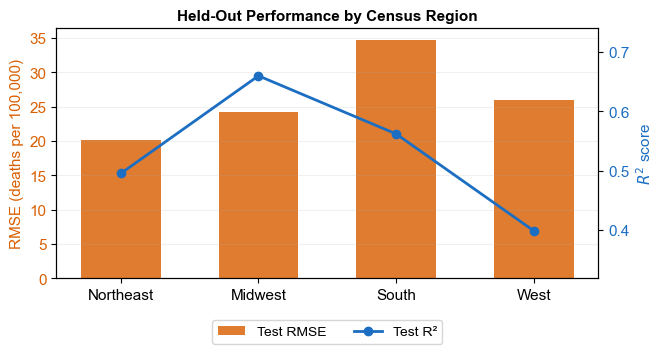

Saved regional heterogeneity figure to: data_cvd/outputs/modeling/xgboost/revision/regional_heterogeneity_performance.png


In [61]:
fig, ax_rmse = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4.1))
plot_df = regional_heterogeneity_metrics.set_index('Census Region').reindex(REGION_ORDER).dropna(subset=['Test RMSE'])
x = np.arange(len(plot_df))

bars = ax_rmse.bar(
    x,
    plot_df['Test RMSE'],
    width=0.58,
    color='#d95f02',
    alpha=0.82,
    label='Test RMSE',
)
ax_rmse.set_ylabel('RMSE (deaths per 100,000)', fontsize=FONT_SIZE, color='#d95f02')
ax_rmse.tick_params(axis='y', labelcolor='#d95f02')
ax_rmse.set_xticks(x)
ax_rmse.set_xticklabels(plot_df.index, fontsize=FONT_SIZE)
ax_rmse.grid(axis='y', alpha=0.18)

ax_r2 = ax_rmse.twinx()
line = ax_r2.plot(
    x,
    plot_df['Test R²'],
    color='#1b6ec2',
    marker='o',
    markersize=6,
    linewidth=2,
    label='Test R²',
)
ax_r2.set_ylabel('$R^2$ score', fontsize=FONT_SIZE, color='#1b6ec2')
ax_r2.tick_params(axis='y', labelcolor='#1b6ec2')
ax_r2.set_ylim(max(0, plot_df['Test R²'].min() - 0.08), min(1, plot_df['Test R²'].max() + 0.08))

handles = [bars, line[0]]
labels = [handle.get_label() for handle in handles]
ax_rmse.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=True, fontsize=10)
ax_rmse.set_title('Held-Out Performance by Census Region', fontsize=FONT_SIZE, fontweight='bold')
fig.tight_layout(rect=[0, 0.08, 1, 1])

regional_heterogeneity_fig_path = OUTPUT_DIR / 'regional_heterogeneity_performance.png'
plt.savefig(regional_heterogeneity_fig_path, dpi=DPI, bbox_inches='tight')
plt.show()

print(f'Saved regional heterogeneity figure to: {project_relative_path(regional_heterogeneity_fig_path)}')


### 19.4 Regional Heterogeneity Artifact Verification

This cell verifies that the regional heterogeneity outputs were written to the configured output directory.


In [62]:
expected_regional_outputs = [
    'regional_heterogeneity_metrics.csv',
    'regional_heterogeneity_performance.png',
]
missing_regional_outputs = [name for name in expected_regional_outputs if not (OUTPUT_DIR / name).exists()]
if missing_regional_outputs:
    raise FileNotFoundError('Missing regional heterogeneity outputs: ' + ', '.join(missing_regional_outputs))

print('Regional heterogeneity artifact check passed:')
for name in expected_regional_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Regional heterogeneity artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/regional_heterogeneity_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/regional_heterogeneity_performance.png


## 20. Revised Choropleth Maps

This section regenerates the county-level choropleth maps with cartographic elements requested for publication review. The maps use a consistent EPSG:5070 projection, include a north arrow and scale bar, and omit in-figure titles so that figure captions carry the descriptive text.


### 20.1 County Geometry and Map Variables

The reduced county-year dataset is aggregated to the quantities needed for the three maps: 2019 CVD mortality, 2012-2019 mean formaldehyde exposure frequency, and 2012-2019 mean wet-bulb temperature.


In [63]:
import importlib.util
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

map_dependencies = {'geopandas': 'geopandas'}
missing_map_dependencies = [name for module, name in map_dependencies.items() if importlib.util.find_spec(module) is None]
if missing_map_dependencies:
    raise ModuleNotFoundError(
        'Missing mapping dependencies: ' + ', '.join(missing_map_dependencies) +
        '. Install them before running the revised choropleth map section.'
    )

import geopandas as gpd

MAP_COUNTY_SHP_PATH = Path('/Users/samyakshrestha/Projects/Life Expectancy Project/data/shapefiles/cb_2019_us_county_20m.shp')
assert MAP_COUNTY_SHP_PATH.exists(), f'Missing county shapefile: {MAP_COUNTY_SHP_PATH.name}'

map_source = pd.read_csv(DATA_PATH)
map_source['FIPS'] = map_source[GROUP_COL].astype(int).astype(str).str.zfill(5)
map_source['CVD Mortality Rate per 100,000'] = map_source[TARGET_COL]
if map_source['CVD Mortality Rate per 100,000'].max() <= 1:
    map_source['CVD Mortality Rate per 100,000'] = map_source['CVD Mortality Rate per 100,000'] * 100000

cvd_2019_map_values = (
    map_source.loc[map_source[YEAR_COL] == 2019, ['FIPS', 'CVD Mortality Rate per 100,000']]
    .drop_duplicates(subset='FIPS')
)
exposure_map_values = (
    map_source
    .groupby('FIPS', as_index=False)
    .agg(
        Formaldehyde_FoT=(FORMALDEHYDE_FEATURE, 'mean'),
        Wet_Bulb_Temperature=('Wet Bulb Temperature', 'mean'),
    )
)

counties_for_maps = gpd.read_file(MAP_COUNTY_SHP_PATH)
if 'GEOID' in counties_for_maps.columns:
    counties_for_maps['FIPS'] = counties_for_maps['GEOID'].astype(str).str.zfill(5)
elif {'STATEFP', 'COUNTYFP'}.issubset(counties_for_maps.columns):
    counties_for_maps['FIPS'] = counties_for_maps['STATEFP'].astype(str).str.zfill(2) + counties_for_maps['COUNTYFP'].astype(str).str.zfill(3)
else:
    raise ValueError('Could not determine county FIPS column from shapefile.')

study_fips_for_maps = set(map_source['FIPS'].unique())
shapefile_fips_for_maps = set(counties_for_maps['FIPS'].unique())
missing_study_fips = sorted(study_fips_for_maps - shapefile_fips_for_maps)
if missing_study_fips:
    raise ValueError(f'Study FIPS missing from county shapefile: {missing_study_fips[:10]}')

EXCLUDE_STATEFP_FOR_MAPS = {'02', '15', '60', '66', '69', '72', '78'}
county_map_gdf = counties_for_maps[~counties_for_maps['STATEFP'].isin(EXCLUDE_STATEFP_FOR_MAPS)].copy()
county_map_gdf = county_map_gdf.merge(cvd_2019_map_values, on='FIPS', how='left')
county_map_gdf = county_map_gdf.merge(exposure_map_values, on='FIPS', how='left')
county_map_gdf = county_map_gdf.to_crs(5070)

expected_map_counties = len(study_fips_for_maps)
matched_map_counties = int(county_map_gdf['FIPS'].isin(study_fips_for_maps).sum())
if matched_map_counties != expected_map_counties:
    missing_display_fips = sorted(study_fips_for_maps - set(county_map_gdf['FIPS']))[:10]
    raise ValueError(f'Displayed {matched_map_counties} of {expected_map_counties} study counties. First missing FIPS: {missing_display_fips}')

for col in ['CVD Mortality Rate per 100,000', 'Formaldehyde_FoT', 'Wet_Bulb_Temperature']:
    data_count = int(county_map_gdf[col].notna().sum())
    if data_count != expected_map_counties:
        raise ValueError(f'{col} has {data_count} counties with data; expected {expected_map_counties}.')


def summarize_map_variable(map_name, variable, period, series, legend_type):
    values = series.dropna()
    return {
        'Map': map_name,
        'Variable': variable,
        'Period': period,
        'Legend Type': legend_type,
        'Projection': 'EPSG:5070',
        'Scale Bar km': 500,
        'North Arrow': True,
        'Counties with Data': int(values.shape[0]),
        'Minimum': float(values.min()),
        '20th Percentile': float(values.quantile(0.20)),
        '40th Percentile': float(values.quantile(0.40)),
        'Median': float(values.median()),
        '60th Percentile': float(values.quantile(0.60)),
        '80th Percentile': float(values.quantile(0.80)),
        'Maximum': float(values.max()),
        'Mean': float(values.mean()),
    }

map_choropleth_summary = pd.DataFrame([
    summarize_map_variable(
        'CVD mortality map',
        'Age-standardized CVD mortality rate (deaths per 100,000 persons)',
        '2019',
        county_map_gdf['CVD Mortality Rate per 100,000'],
        'Quintile classes',
    ),
    summarize_map_variable(
        'Formaldehyde map',
        'FoT formaldehyde above 75th percentile (%)',
        '2012-2019 county mean',
        county_map_gdf['Formaldehyde_FoT'],
        'Continuous color scale',
    ),
    summarize_map_variable(
        'Wet-bulb temperature map',
        'Mean wet-bulb temperature (°C)',
        '2012-2019 county mean',
        county_map_gdf['Wet_Bulb_Temperature'],
        'Continuous color scale',
    ),
])

map_choropleth_summary_path = OUTPUT_DIR / 'map_choropleth_summary.csv'
map_choropleth_summary.to_csv(map_choropleth_summary_path, index=False)

print(f'Contiguous counties displayed: {county_map_gdf.shape[0]:,}')
print(f'Study counties with data: {matched_map_counties:,}')
print(map_choropleth_summary[['Map', 'Counties with Data', 'Minimum', 'Median', 'Maximum', 'Mean']].to_string(index=False))
print()
print(f'Saved choropleth summary to: {project_relative_path(map_choropleth_summary_path)}')


Contiguous counties displayed: 3,108
Study counties with data: 3,061
                     Map  Counties with Data   Minimum     Median    Maximum       Mean
       CVD mortality map                3061 73.103435 258.351484 638.872941 264.034431
        Formaldehyde map                3061  0.209173  22.733449  51.728873  23.344933
Wet-bulb temperature map                3061 -1.190001   9.691175  21.522691   9.808632

Saved choropleth summary to: data_cvd/outputs/modeling/xgboost/revision/map_choropleth_summary.csv


### 20.2 Cartographic Helper Functions

Reusable helper functions add a north arrow, a projected scale bar, and consistent county styling to the revised maps.


In [64]:
def add_north_arrow(ax, x=0.075, y=0.88):
    ax.annotate(
        '',
        xy=(x, y),
        xytext=(x, y - 0.085),
        xycoords='axes fraction',
        arrowprops={'arrowstyle': '-|>', 'lw': 1.4, 'color': 'black', 'mutation_scale': 12},
        zorder=10,
    )
    ax.text(x, y + 0.025, 'N', transform=ax.transAxes, ha='center', va='center', fontsize=FONT_SIZE, fontweight='bold')


def add_scale_bar(ax, length_km=500, x_frac=0.075, y_frac=0.085):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x0 = x_min + (x_max - x_min) * x_frac
    y0 = y_min + (y_max - y_min) * y_frac
    length_m = length_km * 1000
    tick_height = (y_max - y_min) * 0.012
    text_pad = (y_max - y_min) * 0.02

    ax.plot([x0, x0 + length_m], [y0, y0], color='black', linewidth=1.8, solid_capstyle='butt', zorder=10)
    ax.plot([x0, x0], [y0 - tick_height, y0 + tick_height], color='black', linewidth=1.2, zorder=10)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick_height, y0 + tick_height], color='black', linewidth=1.2, zorder=10)
    ax.text(x0 + length_m / 2, y0 + text_pad, f'{length_km} km', ha='center', va='bottom', fontsize=FONT_SIZE - 2, zorder=10)


def finish_map(ax):
    add_north_arrow(ax)
    add_scale_bar(ax)
    ax.set_axis_off()


def save_cvd_quintile_map(gdf, output_path):
    plot_gdf = gdf.copy()
    values = plot_gdf['CVD Mortality Rate per 100,000'].dropna()
    breaks = values.quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).to_numpy()
    if len(np.unique(np.round(breaks, 8))) != len(breaks):
        raise ValueError('CVD mortality quintile breaks are not unique.')

    labels = [f'{breaks[i]:.1f}-{breaks[i + 1]:.1f}' for i in range(len(breaks) - 1)]
    plot_gdf['CVD Mortality Quintile'] = pd.cut(
        plot_gdf['CVD Mortality Rate per 100,000'],
        bins=breaks,
        labels=labels,
        include_lowest=True,
    )
    plot_gdf['CVD Mortality Quintile'] = pd.Categorical(plot_gdf['CVD Mortality Quintile'], categories=labels, ordered=True)

    colors = plt.cm.Oranges(np.linspace(0.28, 0.95, len(labels)))
    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.58), facecolor='white')
    missing_gdf = plot_gdf[plot_gdf['CVD Mortality Rate per 100,000'].isna()]
    if not missing_gdf.empty:
        missing_gdf.plot(ax=ax, color='#d9d9d9', edgecolor='white', linewidth=0.08)
    plot_gdf.dropna(subset=['CVD Mortality Rate per 100,000']).plot(
        column='CVD Mortality Quintile',
        categorical=True,
        cmap=cmap,
        ax=ax,
        edgecolor='white',
        linewidth=0.08,
    )
    handles = [mpatches.Patch(facecolor=colors[i], edgecolor='none', label=labels[i]) for i in range(len(labels))]
    if not missing_gdf.empty:
        handles.append(mpatches.Patch(facecolor='#d9d9d9', edgecolor='none', label='No data'))
    ax.legend(
        handles=handles,
        title='CVD mortality (deaths per 100,000)',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=3,
        frameon=True,
        fontsize=FONT_SIZE - 4,
        title_fontsize=FONT_SIZE - 4,
        borderpad=0.6,
        columnspacing=1.0,
        handlelength=1.4,
    )
    finish_map(ax)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()


def save_continuous_map(gdf, value_col, cmap, legend_label, output_path):
    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.58), facecolor='white')
    missing_gdf = gdf[gdf[value_col].isna()]
    if not missing_gdf.empty:
        missing_gdf.plot(ax=ax, color='#d9d9d9', edgecolor='white', linewidth=0.08)
    gdf.dropna(subset=[value_col]).plot(
        column=value_col,
        cmap=cmap,
        ax=ax,
        legend=True,
        edgecolor='white',
        linewidth=0.08,
        legend_kwds={
            'label': legend_label,
            'orientation': 'horizontal',
            'shrink': 0.56,
            'pad': 0.015,
            'aspect': 35,
        },
    )
    finish_map(ax)
    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()


### 20.3 Revised CVD Mortality Map

The CVD mortality map preserves quintile classification for the 2019 county-level rate while adding compass and scale annotations.


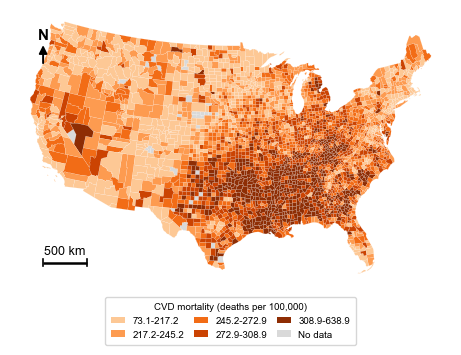

Saved revised CVD mortality map to: data_cvd/outputs/modeling/xgboost/revision/map_cvd_mortality_2019_revised.png


In [65]:
map_cvd_mortality_path = OUTPUT_DIR / 'map_cvd_mortality_2019_revised.png'
save_cvd_quintile_map(county_map_gdf, map_cvd_mortality_path)
print(f'Saved revised CVD mortality map to: {project_relative_path(map_cvd_mortality_path)}')


### 20.4 Revised Atmospheric Predictor Maps

The formaldehyde and wet-bulb temperature maps show county means across 2012-2019 with continuous color scales.


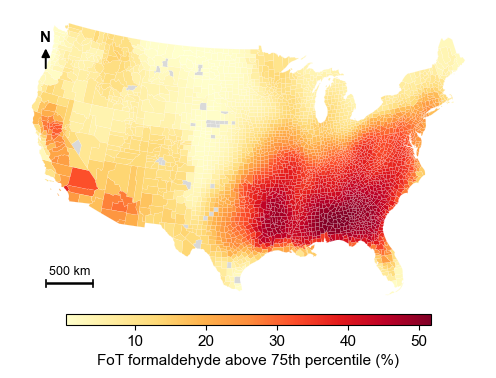

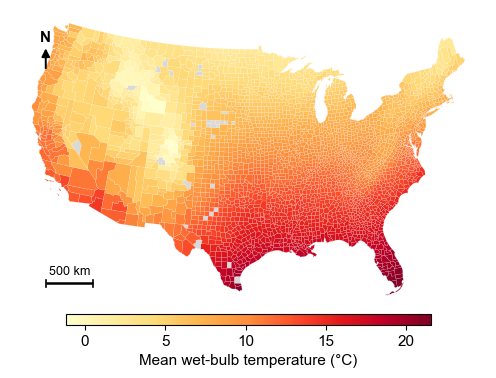

Saved revised formaldehyde map to: data_cvd/outputs/modeling/xgboost/revision/map_formaldehyde_revised.png
Saved revised wet-bulb map to: data_cvd/outputs/modeling/xgboost/revision/map_wetbulb_revised.png


In [66]:
map_formaldehyde_path = OUTPUT_DIR / 'map_formaldehyde_revised.png'
map_wetbulb_path = OUTPUT_DIR / 'map_wetbulb_revised.png'

save_continuous_map(
    county_map_gdf,
    'Formaldehyde_FoT',
    'YlOrRd',
    'FoT formaldehyde above 75th percentile (%)',
    map_formaldehyde_path,
)
save_continuous_map(
    county_map_gdf,
    'Wet_Bulb_Temperature',
    'YlOrRd',
    'Mean wet-bulb temperature (°C)',
    map_wetbulb_path,
)

print(f'Saved revised formaldehyde map to: {project_relative_path(map_formaldehyde_path)}')
print(f'Saved revised wet-bulb map to: {project_relative_path(map_wetbulb_path)}')


### 20.5 Choropleth Artifact Verification

This cell verifies that all revised choropleth map outputs were written to the configured output directory.


In [67]:
expected_map_outputs = [
    'map_choropleth_summary.csv',
    'map_cvd_mortality_2019_revised.png',
    'map_formaldehyde_revised.png',
    'map_wetbulb_revised.png',
]
missing_map_outputs = [name for name in expected_map_outputs if not (OUTPUT_DIR / name).exists()]
if missing_map_outputs:
    raise FileNotFoundError('Missing revised choropleth outputs: ' + ', '.join(missing_map_outputs))

print('Revised choropleth artifact check passed:')
for name in expected_map_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')


Revised choropleth artifact check passed:
- data_cvd/outputs/modeling/xgboost/revision/map_choropleth_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/map_cvd_mortality_2019_revised.png
- data_cvd/outputs/modeling/xgboost/revision/map_formaldehyde_revised.png
- data_cvd/outputs/modeling/xgboost/revision/map_wetbulb_revised.png


## 21. Artifact Manifest and Reviewer Mapping

This section creates a deterministic inventory of revision outputs and maps computational artifacts to reviewer and editor comments. It is an audit step: no models are fit and no figures are recomputed.


### 21.1 Locked Artifact List

The expected output filenames are defined from the locked revision plan. The list includes CSV files, figures, model artifacts, and SHAP arrays generated by the revision notebook.


In [68]:
LOCKED_REVISION_ARTIFACTS = [
    {'Filename': 'canonical_split_metadata.csv', 'Type': 'CSV', 'Section': '1-2', 'Purpose': 'County-grouped train-test split metadata', 'Paper Facing': False, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'canonical_model_metrics.csv', 'Type': 'CSV', 'Section': '3-4', 'Purpose': 'Canonical XGBoost performance metrics', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9; R1.C10'},
    {'Filename': 'canonical_train_predictions.csv', 'Type': 'CSV', 'Section': '4', 'Purpose': 'Canonical training-set predictions and residuals', 'Paper Facing': False, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'canonical_test_predictions.csv', 'Type': 'CSV', 'Section': '4', 'Purpose': 'Canonical held-out test predictions and residuals', 'Paper Facing': False, 'Reviewer Comments': 'R1.C9; R1.C10'},
    {'Filename': 'canonical_shap_ranking.csv', 'Type': 'CSV', 'Section': '7', 'Purpose': 'Canonical mean absolute SHAP ranking', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9; R1.C10'},
    {'Filename': 'canonical_permutation_importance.csv', 'Type': 'CSV', 'Section': '6', 'Purpose': 'Canonical permutation importance ranking', 'Paper Facing': True, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'canonical_shap_dependence_top3_features.csv', 'Type': 'CSV', 'Section': '8', 'Purpose': 'Feature list for top-three SHAP dependence plots', 'Paper Facing': False, 'Reviewer Comments': 'R1.C4; R1.C10'},
    {'Filename': 'canonical_residual_diagnostics_summary.csv', 'Type': 'CSV', 'Section': '9', 'Purpose': 'Canonical residual diagnostic summary', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9'},
    {'Filename': 'canonical_scatter_performance.png', 'Type': 'Figure', 'Section': '5', 'Purpose': 'Observed-versus-predicted canonical model performance', 'Paper Facing': True, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'canonical_shap_summary.png', 'Type': 'Figure', 'Section': '7', 'Purpose': 'Canonical SHAP beeswarm summary', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9; R1.C10'},
    {'Filename': 'canonical_permutation_importance.png', 'Type': 'Figure', 'Section': '6', 'Purpose': 'Canonical permutation importance figure', 'Paper Facing': True, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'canonical_shap_dependence_top3.png', 'Type': 'Figure', 'Section': '8', 'Purpose': 'SHAP dependence plots for top predictors', 'Paper Facing': True, 'Reviewer Comments': 'R1.C4; R1.C10'},
    {'Filename': 'canonical_residual_diagnostics.png', 'Type': 'Figure', 'Section': '9', 'Purpose': 'Canonical residual diagnostics figure', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9'},
    {'Filename': 'canonical_ablation_metrics.csv', 'Type': 'CSV', 'Section': '11', 'Purpose': 'Feature ablation model-performance table', 'Paper Facing': True, 'Reviewer Comments': 'Internal consistency; R1.C10'},
    {'Filename': 'canonical_ablation_curve.png', 'Type': 'Figure', 'Section': '11', 'Purpose': 'Feature ablation performance curve', 'Paper Facing': True, 'Reviewer Comments': 'Internal consistency; R1.C10'},
    {'Filename': 'feature_selection_drop_list.csv', 'Type': 'CSV', 'Section': '12', 'Purpose': 'Dropped predictors from feature-selection audit', 'Paper Facing': False, 'Reviewer Comments': 'R1.C3'},
    {'Filename': 'feature_selection_summary.csv', 'Type': 'CSV', 'Section': '12', 'Purpose': 'Feature-selection audit summary', 'Paper Facing': True, 'Reviewer Comments': 'R1.C3'},
    {'Filename': 'feature_selection_correlated_pairs.csv', 'Type': 'CSV', 'Section': '12', 'Purpose': 'Highly correlated predictor pairs considered during pruning', 'Paper Facing': False, 'Reviewer Comments': 'R1.C3'},
    {'Filename': 'feature_selection_unreduced_model_metrics.csv', 'Type': 'CSV', 'Section': '12', 'Purpose': 'Unreduced model metrics for pruning-impact check', 'Paper Facing': False, 'Reviewer Comments': 'R1.C3'},
    {'Filename': 'feature_selection_model_comparison.csv', 'Type': 'CSV', 'Section': '12', 'Purpose': 'Reduced-versus-unreduced model comparison', 'Paper Facing': True, 'Reviewer Comments': 'R1.C3'},
    {'Filename': 'cams_centroid_grid_cell_counts.csv', 'Type': 'CSV', 'Section': '13', 'Purpose': 'County counts per approximate CAMS grid cell', 'Paper Facing': False, 'Reviewer Comments': 'R1.C2; E.C3'},
    {'Filename': 'cams_grid_summary.csv', 'Type': 'CSV', 'Section': '13', 'Purpose': 'CAMS centroid grid summary statistics', 'Paper Facing': True, 'Reviewer Comments': 'R1.C2; E.C3'},
    {'Filename': 'cams_county_grid_overlap.csv', 'Type': 'CSV', 'Section': '13', 'Purpose': 'County-polygon overlap with approximate CAMS grid cells', 'Paper Facing': False, 'Reviewer Comments': 'R1.C2; E.C3'},
    {'Filename': 'cams_county_grid_overlap_summary.csv', 'Type': 'CSV', 'Section': '13', 'Purpose': 'Summary of counties spanning multiple CAMS grid cells', 'Paper Facing': True, 'Reviewer Comments': 'R1.C2; E.C3'},
    {'Filename': 'cams_grid_histogram.png', 'Type': 'Figure', 'Section': '13', 'Purpose': 'Histogram of counties per approximate CAMS grid cell', 'Paper Facing': False, 'Reviewer Comments': 'R1.C2; E.C3'},
    {'Filename': 'cams_county_grid_overlap_histogram.png', 'Type': 'Figure', 'Section': '13', 'Purpose': 'Histogram of grid cells intersecting each county', 'Paper Facing': False, 'Reviewer Comments': 'R1.C2; E.C3'},
    {'Filename': 'formaldehyde_poverty_shap_data.csv', 'Type': 'CSV', 'Section': '14', 'Purpose': 'County-year data for formaldehyde-poverty SHAP stratification', 'Paper Facing': False, 'Reviewer Comments': 'R1.C3; R2.C1; R2.C7'},
    {'Filename': 'formaldehyde_poverty_quartile_summary.csv', 'Type': 'CSV', 'Section': '14', 'Purpose': 'Poverty-quartile summary of formaldehyde SHAP values', 'Paper Facing': True, 'Reviewer Comments': 'R1.C3; R2.C1; R2.C7'},
    {'Filename': 'formaldehyde_partial_correlation.csv', 'Type': 'CSV', 'Section': '14', 'Purpose': 'Partial correlation after socioeconomic residualization', 'Paper Facing': True, 'Reviewer Comments': 'R1.C3; R1.C4'},
    {'Filename': 'formaldehyde_poverty_quartiles.png', 'Type': 'Figure', 'Section': '14', 'Purpose': 'Formaldehyde SHAP by poverty quartile', 'Paper Facing': True, 'Reviewer Comments': 'R1.C3; R2.C1; R2.C7'},
    {'Filename': 'temporal_metrics.csv', 'Type': 'CSV', 'Section': '15', 'Purpose': 'Temporal validation metrics for 2012-2016 train and 2017-2019 test', 'Paper Facing': True, 'Reviewer Comments': 'R1.C5; R3.C2'},
    {'Filename': 'temporal_test_predictions.csv', 'Type': 'CSV', 'Section': '15', 'Purpose': 'Temporal validation test predictions', 'Paper Facing': False, 'Reviewer Comments': 'R1.C5; R3.C2'},
    {'Filename': 'temporal_scatter_performance.png', 'Type': 'Figure', 'Section': '15', 'Purpose': 'Temporal validation observed-versus-predicted plot', 'Paper Facing': True, 'Reviewer Comments': 'R1.C5; R3.C2'},
    {'Filename': 'shap_stability_fold_ranks.csv', 'Type': 'CSV', 'Section': '16', 'Purpose': 'Fold-level SHAP ranks from GroupKFold stability analysis', 'Paper Facing': False, 'Reviewer Comments': 'R1.C9'},
    {'Filename': 'shap_stability_summary.csv', 'Type': 'CSV', 'Section': '16', 'Purpose': 'SHAP ranking stability summary', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9'},
    {'Filename': 'spatial_mean_residuals_by_county.csv', 'Type': 'CSV', 'Section': '17', 'Purpose': 'Held-out county mean residuals for spatial autocorrelation', 'Paper Facing': False, 'Reviewer Comments': 'R1.C9; E.C3'},
    {'Filename': 'spatial_morans_i.csv', 'Type': 'CSV', 'Section': '17', 'Purpose': "Moran's I residual spatial autocorrelation summary", 'Paper Facing': True, 'Reviewer Comments': 'R1.C9; E.C3'},
    {'Filename': 'spatial_mean_residual_map.png', 'Type': 'Figure', 'Section': '17', 'Purpose': 'Map of held-out county mean residuals', 'Paper Facing': True, 'Reviewer Comments': 'R1.C9; E.C3'},
    {'Filename': 'livestock_sensitivity_metrics.csv', 'Type': 'CSV', 'Section': '18', 'Purpose': 'Full versus no-livestock sensitivity metrics', 'Paper Facing': True, 'Reviewer Comments': 'R1.C8; E.C2; E.C3'},
    {'Filename': 'livestock_sensitivity_shap_ranking.csv', 'Type': 'CSV', 'Section': '18', 'Purpose': 'No-livestock SHAP ranking', 'Paper Facing': False, 'Reviewer Comments': 'R1.C8; E.C2; E.C3'},
    {'Filename': 'livestock_sensitivity_top10_comparison.csv', 'Type': 'CSV', 'Section': '18', 'Purpose': 'Top-10 SHAP comparison with and without livestock predictors', 'Paper Facing': True, 'Reviewer Comments': 'R1.C8; E.C2; E.C3'},
    {'Filename': 'regional_heterogeneity_metrics.csv', 'Type': 'CSV', 'Section': '19', 'Purpose': 'Census-region heterogeneity metrics', 'Paper Facing': True, 'Reviewer Comments': 'R2.C1; R2.C7; R3.C3'},
    {'Filename': 'regional_heterogeneity_performance.png', 'Type': 'Figure', 'Section': '19', 'Purpose': 'Census-region heterogeneity performance figure', 'Paper Facing': True, 'Reviewer Comments': 'R2.C1; R2.C7; R3.C3'},
    {'Filename': 'map_choropleth_summary.csv', 'Type': 'CSV', 'Section': '20', 'Purpose': 'Summary statistics for revised choropleth maps', 'Paper Facing': True, 'Reviewer Comments': 'R2.C3; R3.C4; R4.C2'},
    {'Filename': 'map_cvd_mortality_2019_revised.png', 'Type': 'Figure', 'Section': '20', 'Purpose': 'Revised 2019 CVD mortality choropleth map', 'Paper Facing': True, 'Reviewer Comments': 'R2.C3; R3.C4; R4.C2'},
    {'Filename': 'map_formaldehyde_revised.png', 'Type': 'Figure', 'Section': '20', 'Purpose': 'Revised formaldehyde exposure frequency choropleth map', 'Paper Facing': True, 'Reviewer Comments': 'R2.C3; R4.C2'},
    {'Filename': 'map_wetbulb_revised.png', 'Type': 'Figure', 'Section': '20', 'Purpose': 'Revised wet-bulb temperature choropleth map', 'Paper Facing': True, 'Reviewer Comments': 'R2.C3; R4.C2'},
    {'Filename': 'canonical_shap_values.npy', 'Type': 'Array', 'Section': '7', 'Purpose': 'Canonical test-set SHAP value array', 'Paper Facing': False, 'Reviewer Comments': 'R1.C9; R1.C10'},
    {'Filename': 'canonical_model.json', 'Type': 'Model', 'Section': '3', 'Purpose': 'Serialized canonical XGBoost model', 'Paper Facing': False, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'livestock_sensitivity_shap_values.npy', 'Type': 'Array', 'Section': '18', 'Purpose': 'No-livestock test-set SHAP value array', 'Paper Facing': False, 'Reviewer Comments': 'R1.C8; R1.C9'},
    {'Filename': 'artifact_manifest.csv', 'Type': 'CSV', 'Section': '21', 'Purpose': 'Deterministic inventory of revision outputs', 'Paper Facing': False, 'Reviewer Comments': 'R1.C10'},
    {'Filename': 'reviewer_output_mapping.csv', 'Type': 'CSV', 'Section': '21', 'Purpose': 'Reviewer-comment to notebook-output mapping', 'Paper Facing': False, 'Reviewer Comments': 'R1.C10'},
]

locked_artifacts_df = pd.DataFrame(LOCKED_REVISION_ARTIFACTS)
if locked_artifacts_df['Filename'].duplicated().any():
    duplicates = locked_artifacts_df.loc[locked_artifacts_df['Filename'].duplicated(), 'Filename'].tolist()
    raise ValueError(f'Duplicate locked artifact filenames: {duplicates}')

print(f'Locked revision artifacts: {len(locked_artifacts_df)}')
print(locked_artifacts_df.groupby('Type').size().to_string())


Locked revision artifacts: 52
Type
Array      2
CSV       34
Figure    15
Model      1


### 21.2 Artifact Manifest

The manifest records whether each locked output exists, its type, size, paper-facing status, purpose, and reviewer/editor comment mapping.


In [69]:
def artifact_size_bytes(filename):
    path = OUTPUT_DIR / filename
    return int(path.stat().st_size) if path.exists() else np.nan


def artifact_modified_utc(filename):
    path = OUTPUT_DIR / filename
    if not path.exists():
        return ''
    return pd.Timestamp(path.stat().st_mtime, unit='s', tz='UTC').isoformat()

artifact_manifest_df = locked_artifacts_df.copy()
artifact_manifest_df['Relative Path'] = artifact_manifest_df['Filename'].apply(lambda name: str(project_relative_path(OUTPUT_DIR / name)))
artifact_manifest_df['Exists'] = artifact_manifest_df['Filename'].apply(lambda name: (OUTPUT_DIR / name).exists())
artifact_manifest_df['Size Bytes'] = artifact_manifest_df['Filename'].apply(artifact_size_bytes)
artifact_manifest_df['Modified UTC'] = artifact_manifest_df['Filename'].apply(artifact_modified_utc)
artifact_manifest_df = artifact_manifest_df[
    ['Filename', 'Type', 'Section', 'Purpose', 'Paper Facing', 'Reviewer Comments', 'Relative Path', 'Exists', 'Size Bytes', 'Modified UTC']
]

missing_before_manifest = artifact_manifest_df.loc[
    (~artifact_manifest_df['Exists']) &
    (~artifact_manifest_df['Filename'].isin(['artifact_manifest.csv', 'reviewer_output_mapping.csv'])),
    'Filename',
].tolist()
if missing_before_manifest:
    raise FileNotFoundError('Missing locked revision artifacts before manifest creation: ' + ', '.join(missing_before_manifest))

artifact_manifest_path = OUTPUT_DIR / 'artifact_manifest.csv'
artifact_manifest_df.to_csv(artifact_manifest_path, index=False)

print(f'Artifact manifest rows: {artifact_manifest_df.shape[0]}')
print(f'Paper-facing artifacts: {int(artifact_manifest_df["Paper Facing"].sum())}')
print(f'Missing artifacts before writing audit files: {len(missing_before_manifest)}')
print(f'Saved artifact manifest to: {project_relative_path(artifact_manifest_path)}')


Artifact manifest rows: 52
Paper-facing artifacts: 30
Missing artifacts before writing audit files: 0
Saved artifact manifest to: data_cvd/outputs/modeling/xgboost/revision/artifact_manifest.csv


### 21.3 Reviewer Output Mapping

Reviewer and editor comments are linked to the outputs that support manuscript revisions and response-letter evidence.


In [70]:
REVIEWER_OUTPUT_GROUPS = [
    {
        'Reviewer Comment': 'R1.C2; E.C3',
        'Topic': 'CAMS spatial resolution and exposure-assignment uncertainty',
        'Notebook Outputs': 'cams_grid_summary.csv; cams_county_grid_overlap_summary.csv; cams_centroid_grid_cell_counts.csv; cams_county_grid_overlap.csv; cams_grid_histogram.png; cams_county_grid_overlap_histogram.png',
        'Paper Facing': True,
        'Use in Revision': 'Quantify counties per approximate CAMS grid cell and counties spanning multiple grid cells.',
    },
    {
        'Reviewer Comment': 'R1.C3',
        'Topic': 'Feature selection transparency and pruning impact',
        'Notebook Outputs': 'feature_selection_summary.csv; feature_selection_drop_list.csv; feature_selection_correlated_pairs.csv; feature_selection_model_comparison.csv; feature_selection_unreduced_model_metrics.csv',
        'Paper Facing': True,
        'Use in Revision': 'Document correlated-predictor pruning decisions and compare reduced versus unreduced model performance.',
    },
    {
        'Reviewer Comment': 'R1.C3; R2.C1; R2.C7',
        'Topic': 'Formaldehyde-poverty stratified SHAP analysis',
        'Notebook Outputs': 'formaldehyde_poverty_quartiles.png; formaldehyde_poverty_quartile_summary.csv; formaldehyde_partial_correlation.csv; formaldehyde_poverty_shap_data.csv',
        'Paper Facing': True,
        'Use in Revision': 'Assess whether formaldehyde SHAP signal differs across poverty quartiles and remains after socioeconomic residualization.',
    },
    {
        'Reviewer Comment': 'R1.C5; R3.C2',
        'Topic': 'Temporal validation and temporal evolution',
        'Notebook Outputs': 'temporal_metrics.csv; temporal_test_predictions.csv; temporal_scatter_performance.png',
        'Paper Facing': True,
        'Use in Revision': 'Train on 2012-2016 and test on 2017-2019 to evaluate temporal generalization.',
    },
    {
        'Reviewer Comment': 'R1.C9',
        'Topic': 'SHAP ranking stability',
        'Notebook Outputs': 'shap_stability_summary.csv; shap_stability_fold_ranks.csv',
        'Paper Facing': True,
        'Use in Revision': 'Report formaldehyde rank stability across GroupKFold splits.',
    },
    {
        'Reviewer Comment': 'R1.C9; E.C3',
        'Topic': 'Residual spatial autocorrelation',
        'Notebook Outputs': 'spatial_morans_i.csv; spatial_mean_residuals_by_county.csv; spatial_mean_residual_map.png',
        'Paper Facing': True,
        'Use in Revision': "Report Moran's I for held-out county residuals and discuss spatially structured residual error.",
    },
    {
        'Reviewer Comment': 'R1.C8; E.C2; E.C3',
        'Topic': 'Livestock sensitivity analysis',
        'Notebook Outputs': 'livestock_sensitivity_metrics.csv; livestock_sensitivity_shap_ranking.csv; livestock_sensitivity_top10_comparison.csv; livestock_sensitivity_shap_values.npy',
        'Paper Facing': True,
        'Use in Revision': 'Refit the model without livestock predictors and compare performance and formaldehyde SHAP rank.',
    },
    {
        'Reviewer Comment': 'R2.C1; R2.C7; R3.C3',
        'Topic': 'Census-region heterogeneity analysis',
        'Notebook Outputs': 'regional_heterogeneity_metrics.csv; regional_heterogeneity_performance.png',
        'Paper Facing': True,
        'Use in Revision': 'Report model performance by Census region and discuss regional heterogeneity.',
    },
    {
        'Reviewer Comment': 'R2.C3; R3.C4; R4.C2',
        'Topic': 'Revised choropleth maps',
        'Notebook Outputs': 'map_choropleth_summary.csv; map_cvd_mortality_2019_revised.png; map_formaldehyde_revised.png; map_wetbulb_revised.png',
        'Paper Facing': True,
        'Use in Revision': 'Provide map figures without in-figure titles and with north arrow, scale bar, and missing-data styling.',
    },
    {
        'Reviewer Comment': 'R1.C9; R1.C10',
        'Topic': 'Canonical model reproducibility and interpretability outputs',
        'Notebook Outputs': 'canonical_model_metrics.csv; canonical_scatter_performance.png; canonical_shap_ranking.csv; canonical_shap_summary.png; canonical_permutation_importance.csv; canonical_permutation_importance.png; canonical_shap_dependence_top3.png; canonical_residual_diagnostics_summary.csv; canonical_residual_diagnostics.png; canonical_model.json; canonical_shap_values.npy',
        'Paper Facing': True,
        'Use in Revision': 'Use one canonical model run as the source of truth for model metrics, predictor ranking, and diagnostic figures.',
    },
    {
        'Reviewer Comment': 'Internal consistency; R1.C10',
        'Topic': 'Canonical ablation consistency',
        'Notebook Outputs': 'canonical_ablation_metrics.csv; canonical_ablation_curve.png',
        'Paper Facing': True,
        'Use in Revision': 'Keep Table 3 and ablation figure consistent with the canonical model run.',
    },
    {
        'Reviewer Comment': 'R1.C10',
        'Topic': 'Revision artifact audit',
        'Notebook Outputs': 'artifact_manifest.csv; reviewer_output_mapping.csv',
        'Paper Facing': False,
        'Use in Revision': 'Provide a reproducibility audit trail for all revision outputs.',
    },
]

reviewer_output_mapping_df = pd.DataFrame(REVIEWER_OUTPUT_GROUPS)
known_artifacts = set(locked_artifacts_df['Filename'])
unknown_mapped_outputs = []
for outputs in reviewer_output_mapping_df['Notebook Outputs']:
    for name in [item.strip() for item in outputs.split(';')]:
        if name and name not in known_artifacts:
            unknown_mapped_outputs.append(name)
if unknown_mapped_outputs:
    raise ValueError('Reviewer mapping references unknown artifacts: ' + ', '.join(sorted(set(unknown_mapped_outputs))))

reviewer_output_mapping_path = OUTPUT_DIR / 'reviewer_output_mapping.csv'
reviewer_output_mapping_df.to_csv(reviewer_output_mapping_path, index=False)

print(f'Reviewer mapping rows: {reviewer_output_mapping_df.shape[0]}')
print(reviewer_output_mapping_df[['Reviewer Comment', 'Topic', 'Paper Facing']].to_string(index=False))
print()
print(f'Saved reviewer output mapping to: {project_relative_path(reviewer_output_mapping_path)}')


Reviewer mapping rows: 12
            Reviewer Comment                                                        Topic  Paper Facing
                 R1.C2; E.C3  CAMS spatial resolution and exposure-assignment uncertainty          True
                       R1.C3            Feature selection transparency and pruning impact          True
         R1.C3; R2.C1; R2.C7                Formaldehyde-poverty stratified SHAP analysis          True
                R1.C5; R3.C2                   Temporal validation and temporal evolution          True
                       R1.C9                                       SHAP ranking stability          True
                 R1.C9; E.C3                             Residual spatial autocorrelation          True
           R1.C8; E.C2; E.C3                               Livestock sensitivity analysis          True
         R2.C1; R2.C7; R3.C3                         Census-region heterogeneity analysis          True
         R2.C3; R3.C4; R4.C2          

### 21.4 Final Acceptance Check

The final check verifies that every locked output exists after the manifest and reviewer mapping are written.


In [71]:
final_manifest_check = locked_artifacts_df.copy()
final_manifest_check['Exists'] = final_manifest_check['Filename'].apply(lambda name: (OUTPUT_DIR / name).exists())
final_missing_artifacts = final_manifest_check.loc[~final_manifest_check['Exists'], 'Filename'].tolist()
if final_missing_artifacts:
    raise FileNotFoundError('Missing locked revision artifacts after Phase 11: ' + ', '.join(final_missing_artifacts))

unexpected_revision_files = sorted(
    path.name for path in OUTPUT_DIR.iterdir()
    if path.is_file() and path.name not in set(locked_artifacts_df['Filename'])
)

print('Phase 11 acceptance check passed.')
print(f'Locked artifacts present: {final_manifest_check.shape[0]}')
print(f'Unexpected files in revision output directory: {len(unexpected_revision_files)}')
if unexpected_revision_files:
    print('Unexpected files:')
    for name in unexpected_revision_files:
        print(f'- {name}')


Phase 11 acceptance check passed.
Locked artifacts present: 52
Unexpected files in revision output directory: 0
